# Lesson156 · Temporal leakage audit: trace every information path

Student lab · PROVIDED / TODO / CHECK / EXIT. Default: offline replay of complete real F1 audit evidence, requiring numpy and IPython. Implement three functions; their outputs determine the real report. The optional full gate retrains both five-seed lanes using the pinned GPU environment; it downloads the hash-checked archives and pinned text model. Gates do not impose a dollar cap; author dispatch separately enforces USD10. The source-code cells write only into a fresh temporary directory.

In [ ]:
# @colab-bootstrap: default offline full-data audit; paid training is OFF.
import os,sys,ast,base64,copy,hashlib,json,math,statistics,tempfile,zlib
from pathlib import Path
import numpy as np
from IPython.display import display,Markdown
os.environ.update(OMP_NUM_THREADS='1',OPENBLAS_NUM_THREADS='1',MKL_NUM_THREADS='1')
RUN_FULL_REPRODUCTION=False


In [ ]:
# PROVIDED: frozen primary AUTHOR evidence. No fresh fits in the default lane.
MANIFEST={'scope': 'Ten primary full fits; notebook validation excluded; SHA256 integrity is not an independent human signature', 'files': {'test-dependencies.npz': '438f39f380f2ab7aa654726ac3319a0bd97e40cf8e1e5699fe1004ef16eb106b', 'portfolio-review.json': '5ecff94cb2ea090c998475fc8e8c3722b6f770a69c72b2dc4d24009c8e551b0f', 'val-labels.npz': '471f76059ca72f76600d473d1dbb7a8ea79cdae1bd7bb17c3ae42b1312592f22', 'source-manifest.json': 'dd36de288bb208f35567b4913e4279988f988b6b11fda4099f1dbbc0dc660aec', 'val-dependencies.npz': 'b9a1b87530f97c8025b333e51bac97241ecaf9872c2b2ed1db58be5d56207857', 'protocol.json': '27fc7e049d59bb7b1b07c1999bac484b0bb2923d69e1d683f7c50cc926619864', 'train-labels.npz': 'a3bc6634b77b3a00a8be7eabe5c8b430891f48e8cf1b042cabb5dbdc28568bc5', 'preflight.json': '82c368ca60d6537618ec94ae1390a75be9466715fbfcd2d48b2db60e9cd75d07', 'test-labels.npz': '50a2ad723b98cee1ea22a9f859c2529d7e1dc334d1a7a4d7d2910a6376fdab02', 'label-events.npz': 'b6bcee0684b352e520318351124b3a5bfdf41b29fe8c19c0b92289df6aa88325', 'train-dependencies.npz': '33cef3897a8b68f97f52414684a7d9b5506f4b0389592e0ec6aed049bd998a15', 'correction-protocol.json': '58474b0d2ed5d1f9099a72389c88af7adfbf45f2841277a2b37de1b289da6edd', 'fe/sql-audit.json': '7f006d060809cb60034d8f81f315e80e85f786ee95d994a918c92e96a06ca97b', 'paper/seed-0/result.json': '83483695b55dab46f0eb0857523f4c90f7a5d0993cefa986c3058d82b6e0f59a', 'paper/seed-0/predictions.npz': '6e4ddbba11a35931c42887d34c3f93b647692d3211f581079bc4abe33341e44a', 'paper/seed-0/completed.json': 'b6614a8a4fb40b2eecc8c87ef45f017dc03d04ee255894599fe3cfa6339741e0', 'paper/seed-0/cost.json': 'c826d7dd82e51cb6df9cd776f8fa005438b2ad0a8d3fda72bd4a4455c3fe5500', 'paper/seed-0/temporal-audit.json': 'd58355173c7eeb0ca8a16bb7109318cecc9c2994db1e5243a83ea6bf16e5b689', 'paper/seed-0/audit-l156.json': '8a197ec863627827e302f5b7633766b1f51b483efe0c8f18989fe9d9be501ad9', 'paper/seed-0/diagnostics.json': 'c76321e9a58d2c807f7edd1e77e80950d065bd76ba22aee552b95190c477d052', 'paper/seed-0/audit.json': '0e827bca71558ece6c923d9200e8e1e7811f17d3d53a13884c7ba09610994ac7', 'paper/seed-0/checkpoint-audit.json': '4a069c44ac8f84f35db3ab646a2e2e63facb7bd039835633b43c52ae19c35579', 'paper/seed-1/result.json': '9eef0417d1a4bee6bd04cbb9cb77dc1dc386f3b1b04e2cadec0dce83b45dd2bb', 'paper/seed-1/predictions.npz': '5de33730ea4429db9ed6f54dbf0a3710ffae70c41a97c6c0af5fe242b5e0a061', 'paper/seed-1/completed.json': '9bb89332732b55ac5a5cab0bb311dee6a964e45045b745d189d26d8b1b4c91aa', 'paper/seed-1/cost.json': 'bb4f39026a05ff2b8605a515c66ab18d71e7b8e354c742193bd7cf8b8398d479', 'paper/seed-1/temporal-audit.json': 'e78947ded054e6fb6538cb0df20e1a3215e579d3f22a5ceb1bb81a7e02600a68', 'paper/seed-1/audit-l156.json': 'a1def09c83961ac2f6c58bebf24929dfbe382f6da7962104eab5291fd21c5202', 'paper/seed-1/diagnostics.json': '16a30c7af9f812693dc6f1c449e9aac298d51cfcebc3a05a57a26be45300933b', 'paper/seed-1/audit.json': '0e827bca71558ece6c923d9200e8e1e7811f17d3d53a13884c7ba09610994ac7', 'paper/seed-1/checkpoint-audit.json': '7a61683e22f4a2a671f467729b4183c5b5825e513e33b2ac610c8cf7107226e3', 'paper/seed-2/result.json': 'ddc7456625d554b0a077f457acc175c4de58de2b302b8f758ae7c61f43b93294', 'paper/seed-2/predictions.npz': '640b82f3f7a8d345a9e6598e2ac4bc1fdfe8a08953cbc0af806a4631de4246dc', 'paper/seed-2/completed.json': '5b651fe3e56120843644b6f702c1f66c1d46b12be86f863ba667bc23623d1851', 'paper/seed-2/cost.json': '9c201731af571e583318ff44dd63165dc7e941f1e31eeeddc1e37288d9596a22', 'paper/seed-2/temporal-audit.json': '58245fa0615fcbc80e831af8df6a66fb31e2876d8a8cdb47f427edfd9cd6ec34', 'paper/seed-2/audit-l156.json': '8a197ec863627827e302f5b7633766b1f51b483efe0c8f18989fe9d9be501ad9', 'paper/seed-2/diagnostics.json': 'c490d9ab978382744990a2ca983a8ac7ca4e546e05f1ee86c98e9b900ce11d98', 'paper/seed-2/audit.json': '0e827bca71558ece6c923d9200e8e1e7811f17d3d53a13884c7ba09610994ac7', 'paper/seed-2/checkpoint-audit.json': '25d50ffc8d1df047320fc71e7235d4a6421de03f5ad85433aa74b1fdce931589', 'paper/seed-3/result.json': '1e873e6f9eb5a1c1a53c7c10c30720e876b34f204765d12c6d61cce658fed640', 'paper/seed-3/predictions.npz': '21c8b62837c044bf8f1b9ca0ce6f685d1f4d38bb20a06d831e41284b49186121', 'paper/seed-3/completed.json': 'fd72f3fb2f720ed3d1311b675a8f6c6c7a858700f7aee0977b81b231f5cd6cb6', 'paper/seed-3/cost.json': 'b8cadf2cbf1b4cf686b68b35a08627b817d90d7e96d5ae018706cec12dbc55b4', 'paper/seed-3/temporal-audit.json': 'c445bc48111908707d812e711bb4b73310497f70bec7dbf484486b26fee3497f', 'paper/seed-3/audit-l156.json': 'c85baee4b8d35ffd2ae77656d8fd0fa69bbdcbfbcc3bef8c2db16f7b3f2584d5', 'paper/seed-3/diagnostics.json': 'acce3dfeba13f2c929719488956357c635f778f8b8c8edf5c11932ca3dd0c4ab', 'paper/seed-3/audit.json': '0e827bca71558ece6c923d9200e8e1e7811f17d3d53a13884c7ba09610994ac7', 'paper/seed-3/checkpoint-audit.json': '59b722839a28706919d5bffdd57e73468f4e9af60bcea6faf88931e36d0bde51', 'paper/seed-4/result.json': '02163b455ffca3e855aba3b6d1ccaa9f90480eaefbc335e144b14032f49532ca', 'paper/seed-4/predictions.npz': '6d335d425c29938ff3cc4dc8db521b1241ad7b556d3de2e9a1b5e55f87f3b542', 'paper/seed-4/completed.json': '69bb098465a1916cca3a1eb98751d5592f3743a4e734df8c8792ab5d02cdd1fa', 'paper/seed-4/cost.json': 'b5b6fbadff3cd5a5d1cf3aea488d9735f183151d10dce69987bd7a2584558c9f', 'paper/seed-4/temporal-audit.json': '0aa93e28e719f61b62544b731debbfe20de095e56a9f6863cf1c5d618fc75dfa', 'paper/seed-4/audit-l156.json': 'c85baee4b8d35ffd2ae77656d8fd0fa69bbdcbfbcc3bef8c2db16f7b3f2584d5', 'paper/seed-4/diagnostics.json': '1f38fb6664e770675faba2997b045035291accd2e20f0a1bc96a217b9a6fbdaf', 'paper/seed-4/audit.json': '0e827bca71558ece6c923d9200e8e1e7811f17d3d53a13884c7ba09610994ac7', 'paper/seed-4/checkpoint-audit.json': '21d52cb95c72f2153a1b8bf7d4d4c9fd86a8b88ad04ec43de4d5e4fdb45f5399', 'fit_horizon/seed-0/result.json': '65b1ebc4df627545b2dd303e53d249b97a6a92ec5b6b5fa8888ccf58aeefa5e5', 'fit_horizon/seed-0/predictions.npz': 'e639d34aa63d23b7985fa372274a942b8dcbe053fe03a0522d106cb9f0347126', 'fit_horizon/seed-0/completed.json': '957774168bca2f88b547c15722f80c6bb565a59eb7205f8f464332d7a8650ba4', 'fit_horizon/seed-0/cost.json': 'e94d4ecab61df067855c19de0be6e7042ac38225a42e93ff3e675407672c218c', 'fit_horizon/seed-0/temporal-audit.json': '284d049a0ccdde58f53d32458b1b35c8c7db6a05ab8dac1fc93b2426db28f032', 'fit_horizon/seed-0/audit-l156.json': 'f8812b93166204eefd146ae8ccb840d351a858b3055ef9946553279060a002a6', 'fit_horizon/seed-0/diagnostics.json': '868154b9f8b137a16a94e71018607c9a3ba57aa1a2e6e74843f7d7d91bcd53dc', 'fit_horizon/seed-0/audit.json': 'e724528ebf7f0293e737de75ad03fc241bd46e5e864dd38d37936888a9275450', 'fit_horizon/seed-0/checkpoint-audit.json': '61af719392571cf0531ab8b8f2e092e3a45a23515b0230e12eb4160f40ceb188', 'fit_horizon/seed-1/result.json': 'fb27f8a32a45c71557964de51eaa6dd8a537b8c0b2ad95b7923126a2df16edf9', 'fit_horizon/seed-1/predictions.npz': '13dd8a770f805999f0600b695f87691f7a69a1c85152175118c53a738b8380a3', 'fit_horizon/seed-1/completed.json': 'c7937be79469f5096379d63f05edb069bcbd8fad8de2aed7b140c9972464a6a4', 'fit_horizon/seed-1/cost.json': 'a222de5e43af8497d3dd435b6ff8dcf6cd3e14f62e2f3b0d200dcf304b61dd80', 'fit_horizon/seed-1/temporal-audit.json': '81c1299fbdca997ac5d4778ef26499f36e03757bb999358b3f33be0c2e15b928', 'fit_horizon/seed-1/audit-l156.json': 'b9e254d5efde6e2bb75253b7ccc51722c3b316f7abbb0d48fc68b40bb265f55b', 'fit_horizon/seed-1/diagnostics.json': 'b1e4048d474bea276c8a8541934bc8dc628a3a87c428877908dd7e31511c747d', 'fit_horizon/seed-1/audit.json': 'e724528ebf7f0293e737de75ad03fc241bd46e5e864dd38d37936888a9275450', 'fit_horizon/seed-1/checkpoint-audit.json': 'a31a67da345e48029c709c29131b08f4d6ba97df8e800eea5878bc0584c1e7dc', 'fit_horizon/seed-2/result.json': '91da29325113c8f5fd313ff5e9b084b8d52be7e12879c82c71f3fe9607eb7f8f', 'fit_horizon/seed-2/predictions.npz': '6d6d684e0b4c5529573507c1440c42ffc6ca7f5099992dc71b787d45a8f86e33', 'fit_horizon/seed-2/completed.json': '9e98b6130270759848c96f08b6807419c6c977984d28372d1121872b0a7a7c61', 'fit_horizon/seed-2/cost.json': 'f31ad1b4fcf7cd6c207838ac13a2f15e9adaf372f224a70a6f1383a26ddfce85', 'fit_horizon/seed-2/temporal-audit.json': '98517e6b6d2764b3f6caa2fd3e207c5f644bf9ba32fe74f0e75f4338dc24b236', 'fit_horizon/seed-2/audit-l156.json': 'b9e254d5efde6e2bb75253b7ccc51722c3b316f7abbb0d48fc68b40bb265f55b', 'fit_horizon/seed-2/diagnostics.json': '4dddb5b87a7a5f9305bae9c5159ffd9219700a1106e24d66decf89ee253ac9bf', 'fit_horizon/seed-2/audit.json': 'e724528ebf7f0293e737de75ad03fc241bd46e5e864dd38d37936888a9275450', 'fit_horizon/seed-2/checkpoint-audit.json': '96043ed89c3903ecebc1b4ff4a7f4e5611d074366f018a5fec25b799ba868652', 'fit_horizon/seed-3/result.json': 'd83414b100bd4064cbe62102ba88d9cc2f54a0e6371be030196103ebd601ccbc', 'fit_horizon/seed-3/predictions.npz': '9e995319995edeef51c87fb4c40a3a7c398847f11845df38cad0df8a4dcfcedd', 'fit_horizon/seed-3/completed.json': 'df4eb260a3c79c5876475067f6d388faa53dfe981984c7a9ce4b8b55eba912be', 'fit_horizon/seed-3/cost.json': 'b42ca683f01f5bf2521ef74dba23ee790ed568a1fbd9dc0cd4c762cf67c7f4f8', 'fit_horizon/seed-3/temporal-audit.json': 'f6a92265df913ddb4faabeede431c99e58edbb65cee4c2e0f4172da45a64cb6f', 'fit_horizon/seed-3/audit-l156.json': '36348c29e682fa96375a850273effe8e54a5575bc9189367526167f7f8234ffc', 'fit_horizon/seed-3/diagnostics.json': '8f1c45ba504312c630f74ccf2ff359d4088f3f9a4cf5c3c6481584782fccf678', 'fit_horizon/seed-3/audit.json': 'e724528ebf7f0293e737de75ad03fc241bd46e5e864dd38d37936888a9275450', 'fit_horizon/seed-3/checkpoint-audit.json': 'b7f66b6451931970e77ba320c97632d06f17edd76b62cb5f592de0629a092837', 'fit_horizon/seed-4/result.json': 'd452bc182de888e66ef0c27860a36048069842e1c6fef14c461168289f207f32', 'fit_horizon/seed-4/predictions.npz': 'd16e25cb7eee7541b02da39f047fe6e847addbb12d9d66ee3520689ab56d9875', 'fit_horizon/seed-4/completed.json': 'a04f017ae7a7b8b3023f7bdb75c919f805cc995a40c2900412ee49f77ba67aa4', 'fit_horizon/seed-4/cost.json': '029e6a817720682df0ab717aa6343db590b2751834aa688cbcdcba4ef268b643', 'fit_horizon/seed-4/temporal-audit.json': '1caf2847b1b811e4cfa61e8e8096a77484046105f32dcdd49de4d37032500e2f', 'fit_horizon/seed-4/audit-l156.json': 'dc056105522f6174457d33ab0fd60dfacd5af3bb86e7f492b684f73d898d2e4f', 'fit_horizon/seed-4/diagnostics.json': '3884cf0bce512deced23ed7a8d476af64a32adb441ec308b63a4d753fab63b05', 'fit_horizon/seed-4/audit.json': 'e724528ebf7f0293e737de75ad03fc241bd46e5e864dd38d37936888a9275450', 'fit_horizon/seed-4/checkpoint-audit.json': 'eca3c9451ab78b3a313be0a746943e86eb11a7d5b2aea64ee2862589f737c31c'}}
PACKET='...'
assert hashlib.sha256(PACKET.encode()).hexdigest()=='67616391a685a58918dfb19f27c4beff3fe672f8b4a36140b52796c1c4e9c9b1'
workspace=tempfile.TemporaryDirectory(prefix='l156-audit-');REPLAY_ROOT=Path(workspace.name)/'evidence';REPLAY_ROOT.mkdir()
CODE_ROOT=Path(workspace.name)/'code';(CODE_ROOT/'relkit').mkdir(parents=True)
for name,encoded in json.loads(zlib.decompress(base64.b64decode(PACKET))).items():
 dest=(REPLAY_ROOT/name).resolve();assert dest.is_relative_to(REPLAY_ROOT.resolve())
 raw=base64.b64decode(encoded);assert hashlib.sha256(raw).hexdigest()==MANIFEST['files'][name]
 dest.parent.mkdir(parents=True,exist_ok=True);dest.write_bytes(raw)


## 1 · Trace the information before trusting the score

**Reading route.** Separate event and availability time → rebuild labels → audit both input paths → measure the explicit correction → sign the scope.

**Your win:** produce an evidence-backed temporal audit that can say **PASS**, **FAIL**, or **not established**, and explain the difference. The core reading takes about 30 minutes; the executable audit and full reproduction are a separate lab session.

[Lesson 155](https://avistian.github.io/relational/lessons/0155-compare-manual-fe.html) compared manual features with relational learning on the same F1 queries. It verified scores but left three temporal questions: the SQL uses strict-past history, graph sampling includes equal timestamps, and neither pipeline has complete feature-arrival histories. We now follow information through the entire pipeline. This serves our mission: a predictive advantage matters only if the required information could have been used when the prediction was made.

**Recall the objects.** A relational entity graph, or **REG**, represents table rows as nodes and foreign-key links as edges. A **query** identifies an entity and a prediction cutoff. A driver can have many queries, so the full identity is `(driver_id, cutoff)`. A **label** is the future outcome used for training or evaluation. A **feature** is an input available to the predictor. The same raw result can be a label for an earlier query and a legal historical feature for a later query.

Recall without notes: what owns a cutoff? When can a future outcome be a legal training label?

The primary reading is [RelBench, Section 2: Data Splits](https://arxiv.org/html/2407.20060v1#S2), followed by its [released graph construction](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/modeling/graph.py). Read the actual input population passed to the feature processor. A temporal sampler does not control every information path.



## 2 · There are two clocks, and the query owns the cutoff

> **In plain terms.** “It happened yesterday” and “we learned about it yesterday” are different claims.

**Event time** records when an event occurred. **Availability time** records when the prediction system could first use a value or version. A late-arriving result can have event time 9 and availability time 12. For a query at time 10, that result is too late despite its old event timestamp.

**Worked example, synthetic.** Query A has cutoff 10 and query B has cutoff 20. A sampled result at time 12 belongs to A. Comparing it with the batch maximum, 20, falsely accepts it. The correct comparison uses A's cutoff, 10, at every graph hop. Reaching the result through another entity does not grant a new cutoff.

A strict-past event rule requires `event < cutoff`; an inclusive rule requires `event <= cutoff`. Both additionally require `availability <= cutoff` for a historical availability claim. Equality is a policy question: a timestamp representing the start of a day does not prove that the day's result was already known. Preserve the source boundary and disclose its resolution. Do not silently change every `<=` into `<` and call that reproduction.

A **schedule** is different. A race dated 12 can be a legal input at cutoff 10 if its schedule was published at 9. Applying `event <= cutoff` to schedules would wrongly reject known future plans. Conversely, seeing a schedule in today's archive does not prove it was published before the old query. A field with no timestamp is **timeless in the schema**, not automatically available forever.

On narrow screens, scroll each diagram horizontally; the surrounding worked example provides the same values in text.

<figure class="route-figure" tabindex="0">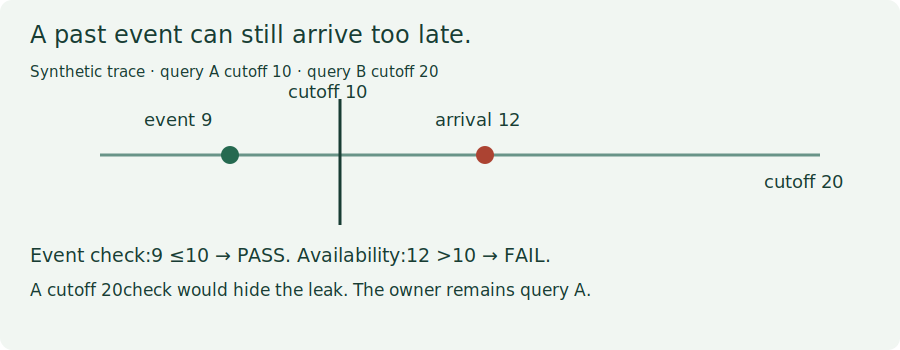<figcaption>Synthetic event 9/arrival 12 at query cutoff 10: event time passes while availability fails. Query B cannot lend its cutoff 20.</figcaption></figure>

Predict: does a passing event-time check prove historical availability? Explain before proceeding.

Predict whether the row should pass before changing its event time, arrival time, or boundary:

Work through the CHECK fixtures: cutoff 10,event9,arrival12fails. Future schedule12published9passes. Unknown arrival prevents historical sign-off.

**Lab task 1 — `audit_observations`.** Evaluate each dependency under its own cutoff and declared kind. A known violation gives FAIL even when another timestamp is missing. If the known conditions pass but availability is missing, return NOT_ESTABLISHED. An empty input is not evidence. The actual SQL lineage replay and fresh training audit call this function.



In [ ]:
# TODO: this function is used by the full evidence replay.
def audit_observations(records):
    raise NotImplementedError("TODO: audit_observations")

In [ ]:
# CHECK: reject wrong boundaries and unsupported certainty.
def rejects(fn):
    try:fn()
    except (ValueError,TypeError):return
    raise AssertionError('Invalid evidence accepted')
def observations():
    return [dict(owner=0,cutoff=10,event=10,available=10,rule='inclusive',kind='event'),
            dict(owner=1,cutoff=20,event=21,available=18,rule='inclusive',kind='schedule'),
            dict(owner=0,cutoff=10,event=9,available=None,rule='strict',kind='event')]
def check_observations(fn):
    r=fn(observations());assert r['status']=='NOT_ESTABLISHED' and r['counts']=={'PASS':2,'FAIL':0,'NOT_ESTABLISHED':1}
    cases=[('event',11),('available',11),('rule','strict')]
    for field,value in cases:
        x=observations();x[0][field]=value
        result=fn(x);assert result['status']=='FAIL' and result['rows'][0]['status']=='FAIL'
    x=observations();x[0]['available']=None;x[0]['event']=11
    assert fn(x)['status']=='FAIL','Known future cannot be excused by missing arrival time'
    x=observations();x[1]['available']=21;assert fn(x)['rows'][1]['status']=='FAIL'
    for field,value in [('event',float('nan')),('cutoff',float('inf')),('rule','maybe'),('kind','anything')]:
        x=observations();x[0][field]=value;rejects(lambda:fn(x))
    x=observations();x[2]['cutoff']=12;rejects(lambda:fn(x))
    rejects(lambda:fn([]))
check_observations(audit_observations)
print("PASS audit_observations")

## 3 · Labels belong after the cutoff; inputs do not inherit that permission

The F1 task asks for a driver's mean finishing position over the next 60 days. Its label window is **`(cutoff, cutoff + 60 days]`**: exclude the left boundary and include the right. An entity without a future participation label is absent from this benchmark's query population. This is a benchmark conditioned on future participation, not an unrestricted deployment population of every driver.

**Worked example, synthetic.** At cutoff 10 with horizon 5, result values are 99 at time 10, 2 at time 11, 6 at time 15, and 99 at time 16. Only 2 and 6 contribute: label `(2 + 6) / 2 = 4`. Using either boundary incorrectly changes the answer. Changing prediction order must not change the score; matching only driver ID can.

**Label maturity** asks whether a training label's observation window ended before the model's training completion time. We verify the latest training window ends by the 2005 validation boundary, and the latest validation window ends by the 2010 test boundary. Validation outcomes may select the checkpoint; test outcomes may score the frozen selection. Reusing a previously exposed test split is a reproduction, not untouched confirmation.

**Lab task 2 — `audit_label_windows`.** Rebuild every supplied mean from raw events using complete query keys. Reject duplicate queries and nonfinite values; return a failed audit for a mismatched or empty label window. The full audit separately reconstructs each cutoff's eligible entity set so checking only the supplied rows cannot hide missing queries.

<figure class="route-figure" tabindex="0">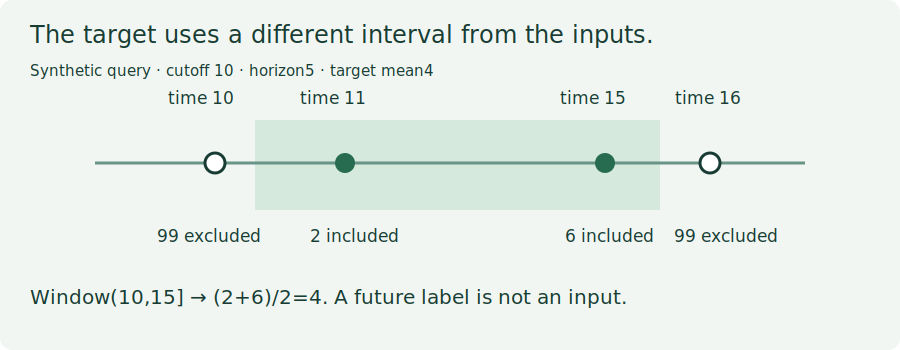<figcaption>Synthetic label trace: include times 11 and 15 in (10,15], exclude 10 and 16, mean(2+6)/2=4.</figcaption></figure>



In [ ]:
# TODO: this function is used by the full evidence replay.
def audit_label_windows(queries, events, horizon):
    raise NotImplementedError("TODO: audit_label_windows")

In [ ]:
# CHECK: reject wrong boundaries and unsupported certainty.
def rejects(fn):
    try:fn()
    except (ValueError,TypeError):return
    raise AssertionError('Invalid evidence accepted')
def observations():
    return [dict(owner=0,cutoff=10,event=10,available=10,rule='inclusive',kind='event'),
            dict(owner=1,cutoff=20,event=21,available=18,rule='inclusive',kind='schedule'),
            dict(owner=0,cutoff=10,event=9,available=None,rule='strict',kind='event')]
def check_labels(fn):
    q=[dict(entity=1,time=10,target=4.),dict(entity=1,time=20,target=8.)]
    e=[dict(entity=1,time=10,value=99.),dict(entity=1,time=11,value=2.),dict(entity=1,time=15,value=6.),dict(entity=1,time=21,value=8.),dict(entity=1,time=26,value=99.)]
    r=fn(q,e,5);assert r['status']=='PASS' and r['queries']==2 and r['label_events']==3
    x=copy.deepcopy(q);x[0]['target']=99.;assert fn(x,e,5)['status']=='FAIL'
    x=copy.deepcopy(q);x[0]['time']=15;assert fn(x,e,5)['status']=='FAIL'
    rejects(lambda:fn(q+q[:1],e,5));rejects(lambda:fn(q,e,0));rejects(lambda:fn([],e,5))
    x=copy.deepcopy(q);x[0]['target']=float('nan');rejects(lambda:fn(x,e,5))
check_labels(audit_label_windows)
print("PASS audit_label_windows")

## 4 · Follow both paths into the prediction

> **In plain terms.** Blocking a future neighbor does not stop a future row from influencing the encoder's fitted statistics.

A **feature processor** converts raw columns into numerical tensors. It can learn numerical means, time ranges and categorical vocabularies. **Type inference** decides which kind of processor a column receives. Both have a fitting population. **Transforming** later rows with an already fitted processor is different from fitting again on them.

The released GNN constructs features from database rows through **2010-01-01**, the test cutoff. Its neighbor loader then filters dated rows for each query. This follows the [pinned implementation](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/examples/gnn_node.py). It is not proof that the processors could have been fitted when training ended in 2005.

Our declared **fit-horizon policy** requires dated-table type discovery and feature-processor fitting to use rows dated no later than **2005-01-01**. The audit finds that the released preprocessing violates this policy. This is a separate verdict from source parity. It does not show that future labels were directly fed into the neural network, and it does not establish the size or direction of any score effect.

<figure class="route-figure" tabindex="0">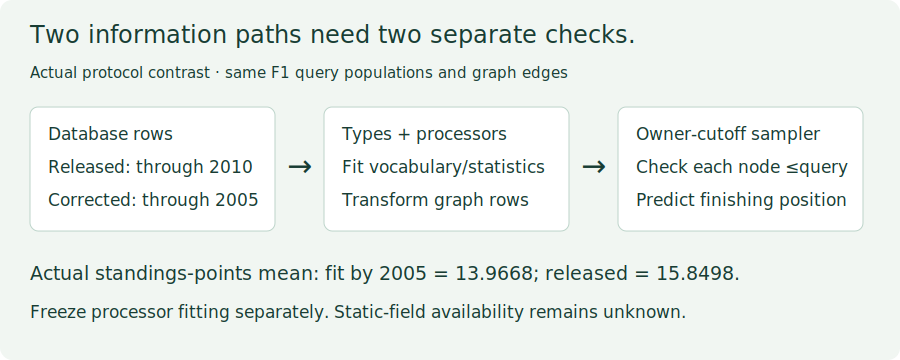<figcaption>Actual released and corrected information paths. Preprocessing population and owner-cutoff sampling are separate checks.</figcaption></figure>

The correction fits dated-table processors using the permitted population and uses their fixed conversion on every graph row. It preserves graph identities and event timestamps. The training recipe, query populations, validation selection and evaluation rule remain fixed. Vocabulary or inferred-type changes can alter encoder dimensions; this intervention concerns the complete preprocessing policy, not only one scalar mean.

**A crucial distinction:** these are frozen processors fitted when model training ends. They may use matured training history later than an early training query. We do not pretend this is a separate model retrained at every historical query cutoff. If that is the deployment question, it needs its own rolling-origin experiment.

The FE pipeline already fits its tabular processor on training feature rows. Its SQL still needs an audit of the inputs used to create those rows. We regenerate every feature and independently reconstruct all 50 engineered fields. Result and standings history passes the source event-date conditions. Upcoming race fields have future event dates, but their publication histories are missing. Static driver and constructor attributes have no version history. The SQL percentage-of-laps denominator also depends on eligible joined query rows within each split. Exact source reconstruction does not establish a feature independent of that benchmark cohort. Neither arm earns a historical availability guarantee.

> **Scope check.** The corrected GNN still retains static-table rows without proven creation/arrival times. Its dated-table cutoff is an event-time proxy. Correcting that demonstrated fit-scope violation cannot recover missing ingestion histories, historical versions, or a different deployment cohort.



## 5 · Reproduce first, correct explicitly, then measure

**Named experiment:** `L156 rel-f1/driver-position — temporal audit of released RDL and manual-FE pipelines`.

The released lane runs all 7,453 training, 499 validation and 760 test queries. Five seeds each train ten full epochs. The model uses typed row encoders, relative time, two 128-channel sum-GraphSAGE layers and a scalar head. It uses Adam at 0.005, batches of 512, L1 loss and uniform 128/64 neighbor fanouts. The first strict validation-MAE minimum selects the checkpoint. Predictions are clipped to the training-target 2nd/98th percentiles, as in the released evaluator. **MAE** is mean absolute prediction error, measured in finishing-position units; lower is better.

The corrected lane repeats all five complete fits with the frozen preprocessing policy from Section 4. The policy was written before inspecting corrected scores. It is a course intervention, separate from the paper-table reproduction. We do not select whichever temporal policy happens to score better on test.

**During every yielded batch:** compare roots with the source task table, verify original node and edge identities, reject cross-query edges, and check each dated node against its owner's cutoff. The new function checks timestamp maxima separately for each owner and table; the existing identity checker still examines every sampled node and edge. Passing the sampled census covers those draws, not every possible stochastic neighborhood. On each split's first batch, forged root cutoffs and node times must be rejected.

| Lane | Validation MAE | Test MAE | Strict fit/availability verdict |
|---|---:|---:|---|
| Released source | 3.1842 ± 0.0332 | 4.1283 ± 0.2222 | FAIL |
| Fit by 2005 correction | 3.2035 ± 0.0424 | 4.2004 ± 0.2696 | NOT_ESTABLISHED |


<figure class="route-figure" tabindex="0">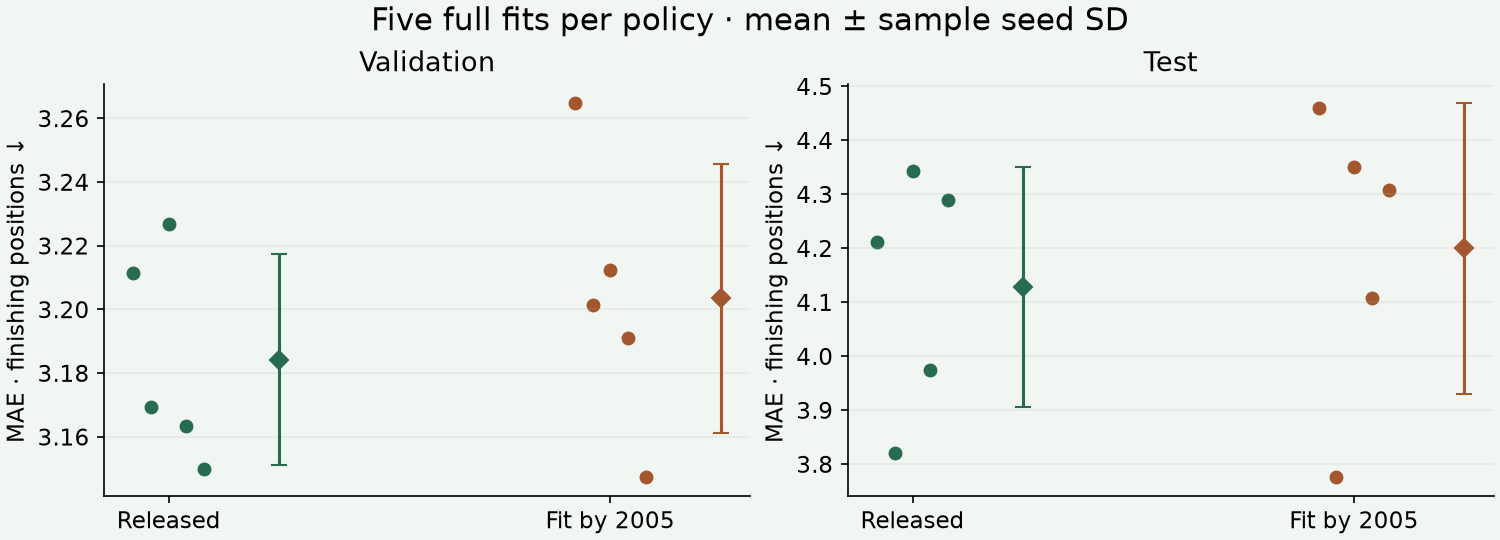<figcaption>Actual primary five-seed runs per policy. Points are seeds; diamonds and bars are mean and sample seed SD. Separate validation/test scales.</figcaption></figure>

**Measured consequence:** corrected minus released test MAE is **+0.0721 finishing positions**. Positive means the corrected lane is worse. The temporal policy is justified by its information contract, not by a preferred score. The released mean's frozen ±0.20 comparison with Table 7 is **CLOSE**; the corrected lane is not that published experiment.

Points are individual seeds; bars show mean ± sample seed standard deviation. Seed variation describes these fits on one database. Matching integer seeds across policies does not make identical initial weights when preprocessing changes dimensions. The difference is descriptive; no population-level superiority or equivalence claim follows.

**Measured coverage:** all 8,712 labels, 443,552 independently reconstructed SQL values, and 12,590 held-out predictions across ten primary fits. Each lane audits 403,895 yielded query occurrences. The released lane checks 56,097,400 dated-node occurrences and 130,667,821 edge occurrences; these are repeated sampled occurrences, not unique database rows. Equality-boundary occurrences: 51,049. Nonfinite first-backward entries per released seed: [640, 640, 640, 640, 640]. [Machine-readable coverage](https://avistian.github.io/relational/labs/evidence/l156/report.json).

**Delivery evidence:** the standalone 30-code-cell audit notebook passed in an empty directory. Its full pinned GPU gate ran ten additional complete fits and independently checked another 12,590 predictions, excluded from the primary means. A controlled future-row perturbation left corrected fit statistics unchanged and changed the released control. Reserved worker resources plus the overhead allowance total **$7.47**, within the **$10 aggregate cap**; this is not an invoice. [Budget ledger](https://avistian.github.io/relational/labs/_budget_l156.json). Live Colab and deployment remain NOT_CHECKED.

The first backward pass also records nonfinite gradient entries inherited from the source numeric encoder. They are an optimization-health limitation, separate from temporal leakage. We preserve them rather than silently repairing another mechanism inside this experiment.



## 6 · Sign the scope, not a universal promise

A reusable checklist needs **claim, policy, coverage, evidence and verdict** for each item. A source hash ties a report to bytes; it is not a signature from an independent reviewer. A completed audit can honestly conclude that legality is not established.

| Check | Evidence required | What a pass does not prove |
|---|---|---|
| Query identity | Complete `(entity, cutoff)` key set and root/task agreement | Arrival history |
| Label window/cohort | Rebuilt values, eligible entities, boundary and maturity checks | Deployment population equivalence |
| Sampled graph | Original identities, owner cutoffs, no cross-query edges | Every possible draw or mutable attributes |
| SQL features | Value reconstruction and joined-row time conditions | Publication of scheduled events |
| Processor fitting | Type/vocabulary/statistic fitting population and frozen conversion | Static fields existed historically |
| Availability | Ingestion/publication/version history or explicit missing evidence | Event dates alone are insufficient |
| Model selection | Complete validation trace and first-best rule | Pristine test data after prior exposure |
| Scores | Finite predictions aligned to complete keys | Information legality or superiority |

**Lab task 3 — `audit_verdict`.** Require all declared checks. Known failures dominate; missing checks prevent sign-off; unobserved histories remain NOT_ESTABLISHED. A PASS needs every required check and evidence. The final report calls your function for both real experiment lanes.

**Portfolio coverage:** F1 receives the new full census and fresh instrumented fits. The classification entry has existing completed fits, but a fresh L156 execution of its new auditor is **NOT_RUN**. Recommendation retains its earlier 32-batch validation pilot: full reproduction **INCOMPLETE**, test **NOT_RUN**. Reviewing their pinned contracts does not close those gaps. [Coverage record](https://avistian.github.io/relational/labs/evidence/l156/portfolio-review.json).

**Fixing a leak means tracing its cause.** A mutated batch-maximum checker is repaired by indexing the original owner cutoff. A future fitted statistic is repaired by fitting on the declared historical population and transforming later inputs without refitting. A missing schedule history requires better evidence or an explicitly different feature policy; replacing missing timestamps with event dates manufactures certainty. Score improvements are never the acceptance criterion for a temporal repair.



In [ ]:
# TODO: this function is used by the full evidence replay.
def audit_verdict(checks, required):
    raise NotImplementedError("TODO: audit_verdict")

In [ ]:
# CHECK: reject wrong boundaries and unsupported certainty.
def rejects(fn):
    try:fn()
    except (ValueError,TypeError):return
    raise AssertionError('Invalid evidence accepted')
def observations():
    return [dict(owner=0,cutoff=10,event=10,available=10,rule='inclusive',kind='event'),
            dict(owner=1,cutoff=20,event=21,available=18,rule='inclusive',kind='schedule'),
            dict(owner=0,cutoff=10,event=9,available=None,rule='strict',kind='event')]
def check_verdict(fn):
    required=['cutoff','arrival','labels']
    c=[dict(id='cutoff',status='PASS',evidence='sha256:a'),dict(id='arrival',status='NOT_ESTABLISHED',evidence='missing history'),dict(id='labels',status='PASS',evidence='sha256:b')]
    assert fn(c,required)['status']=='NOT_ESTABLISHED'
    assert fn(c[:1],required)['status']=='NOT_CHECKED'
    x=copy.deepcopy(c);x[0]['status']='FAIL';assert fn(x,required)['status']=='FAIL'
    x=copy.deepcopy(c);x[1]['status']='PASS';assert fn(x,required)['status']=='PASS'
    x=copy.deepcopy(c);x[0]['evidence']='';rejects(lambda:fn(x,required))
    rejects(lambda:fn(c+c[:1],required));rejects(lambda:fn(c,[]))
    x=copy.deepcopy(c);x[0]['status']='COMPLETE';rejects(lambda:fn(x,required))
    x=copy.deepcopy(c);x[0]['status']='FAIL';assert fn(x[:1],required)['status']=='FAIL'
check_verdict(audit_verdict)
print("PASS audit_verdict")

### PROVIDED · Independent replay

The visible code verifies input hashes, reconstructs all labels and actual SQL dependencies, aligns held-out predictions, checks all training epochs and validation selections, and calls your sign-off function. A human signature is not fabricated.

In [ ]:
def verify_inputs(root,manifest):
    root=Path(root)
    for name,digest in manifest['files'].items():
        p=(root/name).resolve()
        if not p.is_relative_to(root.resolve()):raise ValueError('Unsafe path')
        if hashlib.sha256(p.read_bytes()).hexdigest()!=digest:raise ValueError('Changed evidence: '+name)

In [ ]:
def replay(root,manifest,observations=audit_observations,labels=audit_label_windows,verdict=audit_verdict):
    root=Path(root);verify_inputs(root,manifest)
    pre=json.loads((root/'preflight.json').read_text());sql=json.loads((root/'fe/sql-audit.json').read_text())
    assert pre['status']==sql['status']=='PASS'
    a=np.load(root/'label-events.npz');events=[dict(entity=int(e),time=int(t),value=float(y)) for e,t,y in zip(a['entity'],a['time'],a['value'])]
    label_counts={};deps={};truth={}
    for split,n in [('train',7453),('val',499),('test',760)]:
        a=np.load(root/f'{split}-labels.npz')
        qs=[dict(entity=int(e),time=int(t),target=float(y)) for e,t,y in zip(a['entity'],a['time'],a['target'])]
        r=labels(qs,events,60*86400);assert r['status']=='PASS' and r['queries']==n;label_counts[split]=n
        truth[split]={(q['entity'],q['time']*10**9):q['target'] for q in qs}
        x=np.load(root/f'{split}-dependencies.npz')
        records=[dict(owner=int(i),cutoff=int(t),event=int(e) if k!='static' else None,available=None,rule='strict' if k=='event' else 'inclusive',kind=str(k)) for i,t,e,k in zip(x['owner'],x['cutoff'],x['event'],x['kind'])]
        r=observations(records);assert r['status']=='NOT_ESTABLISHED' and r['counts']['FAIL']==0;deps[split]=r['counts']
    lanes={};all_predictions=0
    for lane in ['paper','fit_horizon']:
        records=[];coverage={k:0 for k in ['queries','batches','dated_node_occurrences','edge_occurrences','equality_nodes','owner_table_checks']};gradient={};maxerr=0
        for seed in range(5):
            p=root/lane/f'seed-{seed}';r=json.loads((p/'result.json').read_text());done=json.loads((p/'completed.json').read_text());t=json.loads((p/'temporal-audit.json').read_text());new=json.loads((p/'audit-l156.json').read_text())
            assert done['status']=='COMPLETE' and r['epochs']==10 and len(r['trace'])==10
            assert [x['epoch'] for x in r['trace']]==list(range(1,11)) and all(x['train_queries']==7453 for x in r['trace'])
            assert r['selected_epoch']==min(r['trace'],key=lambda x:x['val_mae'])['epoch']
            assert new['lane']==('released' if lane=='paper' else 'fit_horizon')
            assert t['status']==new['status']=='PASS' and len(new['mutants_rejected'])==6
            assert done['seed']==r['seed']==seed
            for k in ['queries','batches','dated_node_occurrences','edge_occurrences']:coverage[k]+=sum(s[k] for s in t['splits'].values())
            for k in ['equality_nodes','owner_table_checks']:coverage[k]+=sum(s[k] for s in new['splits'].values())
            if lane=='fit_horizon':
                for item in new['preprocessing'].values():
                    if item['status']=='PASS':assert item['latest_fit_event']<='2005-01-01 00:00:00'
            a=np.load(p/'predictions.npz');scores={}
            for split in ['val','test']:
                keys=list(zip(a[split+'_entity'].tolist(),a[split+'_time'].tolist()))
                assert len(set(keys))==len(keys) and set(keys)==set(truth[split])
                expected=np.array([truth[split][k] for k in keys]);np.testing.assert_allclose(expected,a[split+'_target'],rtol=0,atol=1e-12)
                pred=a[split+'_pred'];assert np.isfinite(pred).all();scores[split]=float(np.abs(pred-expected).mean())
                assert abs(scores[split]-r['scores'][split])<1e-12;all_predictions+=len(keys)
                maxerr=max(maxerr,r['replay'][split]['max_original_logit_error'])
            gradient[str(seed)]=sum(json.loads((p/'diagnostics.json').read_text())['first_backward_nonfinite'].values())
            records.append(dict(seed=seed,selected_epoch=r['selected_epoch'],**scores))
        metrics={s:dict(mean=statistics.mean(r[s] for r in records),sd=statistics.stdev(r[s] for r in records)) for s in ['val','test']}
        checks=[dict(id=k,status='PASS',evidence='hash-bound complete audit inputs') for k in ['query_identity','label_windows','sampling','fe_history','selection','prediction_keys']]
        checks.extend([dict(id='fit_scope',status='FAIL' if lane=='paper' else 'PASS',evidence='Declared2005-01-01dated-table fit horizon; released2010-01-01materialization' if lane=='paper' else 'Every dated processor fitted by2005-01-01'),dict(id='availability',status='NOT_ESTABLISHED',evidence='No ingestion,static attribute version or schedule publication histories')])
        required=['query_identity','label_windows','sampling','fe_history','fit_scope','availability','selection','prediction_keys']
        signoff=verdict(checks,required)
        assert signoff['status']==('FAIL' if lane=='paper' else 'NOT_ESTABLISHED')
        lanes[lane]=dict(records=records,metrics=metrics,coverage=coverage,checks=checks,strict_policy_verdict=signoff,first_backward_nonfinite=gradient,original_model_max_error=maxerr)
    delta={s:lanes['fit_horizon']['metrics'][s]['mean']-lanes['paper']['metrics'][s]['mean'] for s in ['val','test']}
    return dict(status='PASS',experiment='L156 full F1 temporal audit',label_counts=label_counts,dependencies=deps,sql_values=sql['total_values'],lanes=lanes,corrected_minus_released_mae=delta,predictions=all_predictions,reference_paper_band={s:'CLOSE' if abs(lanes['paper']['metrics'][s]['mean']-target)<=.2 else 'OUTSIDE_TOLERANCE' for s,target in [('val',3.193),('test',4.022)]},availability='NOT_ESTABLISHED',whole_paper='NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')

In [ ]:
def render_report(r):
    lines=['# Lesson156 · Temporal audit report','', 'Full archived F1 audit and five fresh complete fits per lane. Author evidence; learner PENDING_WRITTEN_DEFENSE.','', '| Lane | Validation MAE mean ± seed SD | Test MAE mean ± seed SD | Strict policy verdict |','|---|---:|---:|---|']
    for name,lane in r['lanes'].items():
        v=lane['metrics']['val'];t=lane['metrics']['test'];lines.append(f"| {name} | {v['mean']:.6f} ± {v['sd']:.6f} | {t['mean']:.6f} ± {t['sd']:.6f} | {lane['strict_policy_verdict']['status']} |")
    lines+=['',f"Labels: {sum(r['label_counts'].values()):,}; independently reconstructed SQL values: {r['sql_values']:,}; scored held-out predictions: {r['predictions']:,}.",f"Corrected minus released test MAE: {r['corrected_minus_released_mae']['test']:+.6f}; positive is worse. Descriptive, one database, no superiority inference.",'','The released lane matches the released preprocessing protocol, but fails the declared2005-01-01fit-horizon policy. The correction fits dated-table types and processors by that horizon; it is a course intervention, not Table7 parity. Static histories and schedule publication remain unobserved. No leak-free sign-off.','',f"Reference paper comparison: {r['reference_paper_band']}. Whole paper NOT_RUN; historical identity NOT_ESTABLISHED. First-backward nonfinite gradient counts remain in the JSON."]
    return '\n'.join(lines)+'\n'

In [ ]:
report=replay(REPLAY_ROOT,MANIFEST,observations=audit_observations,labels=audit_label_windows,verdict=audit_verdict)
assert report["predictions"]==12590
display(Markdown(render_report(report)))

## 7 · Exit: defend the boundary you actually checked

[Student notebook](https://avistian.github.io/relational/labs/0156-temporal-leakage-audit.ipynb) · [Worked notebook](https://avistian.github.io/relational/labs/html/0156-temporal-leakage-audit.html) · [Teacher solution](https://avistian.github.io/relational/labs/solutions/0156-temporal-leakage-audit.ipynb) · [Reference checklist](https://avistian.github.io/relational/reference/reg-temporal-leakage-audit.html) · [Measured report](https://avistian.github.io/relational/labs/evidence/l156/report.md) · [Reproduction contract](https://avistian.github.io/relational/labs/l156-reproduction.md).

Complete the three live functions, export your audit, and write 250–400 words. Name one demonstrated policy violation, explain its correction and measured consequence, and defend why historical availability is still unknown. Distinguish source parity, sampled event-time legality, fit-time policy and original availability. Include the coverage boundary of the other portfolio tasks.

The teaching agent grades policy clarity, owner/query reasoning, evidence coverage, correction interpretation and honest conclusion, 0–2 each. Readiness needs 8/10 with no zero. Author execution leaves **PENDING_WRITTEN_DEFENSE**. Tomorrow reconstruct the two-clock counterexample without notes. In a week, audit a schedule published before its future event and a late-arriving past result.

Write your defense before comparing against the teaching agent's feedback.

Ask the agent follow-up questions about any boundary or missing history. [Lesson 157](https://avistian.github.io/relational/lessons/0157-open-source-contribution.html) packages reproducible work for others; this audit determines which claims that package may carry.


In [ ]:
# EXIT: attach your scoped defense; mastery requires review.
WRITTEN_DEFENSE=""
Path('l156-audit-report.json').write_text(json.dumps(dict(report,written_defense=WRITTEN_DEFENSE),indent=2))
Path('l156-audit-report.md').write_text(render_report(report)+'\n'+WRITTEN_DEFENSE)
Path('l156-report.json').write_text(json.dumps(dict(status='PASS',predictions=report['predictions'],labels=sum(report['label_counts'].values()),learner='PENDING_WRITTEN_DEFENSE'),indent=2))


## Optional full reproduction · visible implementation

Use Python3.11, Torch2.5.1/CUDA12.4, Frame0.2.3, PyG2.6.1, pyg-lib0.4.0 and the remaining exact requirements in the transported file. The [Modal recipe](https://avistian.github.io/relational/modal/l156_notebook_check.py) specifies the environment. Set `RUN_FULL_REPRODUCTION=True` in the bootstrap cell only in that runtime, then run all. These code cells write the visible implementation into an isolated directory. They do not execute training until the final gate. Full model, graph construction, trainer, original identity auditor and new correction are shown below. Only original licensed reference sources are transported as data.

In [ ]:
# PROVIDED: unchanged licensed upstream sources for original-model parity.
VENDOR={'sources/l117/utils.py': 'from typing import Any, Dict\n\nimport numpy as np\nimport pandas as pd\nfrom torch_frame import stype\nfrom torch_frame.utils import infer_df_stype\n\nfrom relbench.base import Database, Table\n\n\ndef to_unix_time(ser: pd.Series) -> np.ndarray:\n    r"""Converts a :class:`pandas.Timestamp` series to UNIX timestamp (in seconds)."""\n    assert ser.dtype in [np.dtype("datetime64[s]"), np.dtype("datetime64[ns]")]\n    unix_time = ser.astype("int64").values\n    if ser.dtype == np.dtype("datetime64[ns]"):\n        unix_time //= 10**9\n    return unix_time\n\n\ndef remove_pkey_fkey(col_to_stype: Dict[str, Any], table: Table) -> dict:\n    r"""Remove pkey, fkey columns since they will not be used as input feature."""\n    if table.pkey_col is not None:\n        if table.pkey_col in col_to_stype:\n            col_to_stype.pop(table.pkey_col)\n    for fkey in table.fkey_col_to_pkey_table.keys():\n        if fkey in col_to_stype:\n            col_to_stype.pop(fkey)\n\n\ndef get_stype_proposal(db: Database) -> Dict[str, Dict[str, stype]]:\n    r"""Propose stype for columns of a set of tables in the given database.\n\n    Args:\n        db (Database): The database object containing a set of tables.\n\n    Returns:\n        Dict[str, Dict[str, Any]]: A dictionary mapping table name into\n            :obj:`col_to_stype` (mapping column names into inferred stypes).\n    """\n\n    inferred_col_to_stype_dict = {}\n    for table_name, table in db.table_dict.items():\n        df = table.df\n        df = df.sample(min(1_000, len(df)))\n        inferred_col_to_stype = infer_df_stype(df)\n        # Hack for now. This is relevant for rel-amazon.\n        for col, stype_ in inferred_col_to_stype.items():\n            if stype_.value == "embedding":\n                inferred_col_to_stype[col] = stype.multicategorical\n        inferred_col_to_stype_dict[table_name] = inferred_col_to_stype\n\n    return inferred_col_to_stype_dict\n', 'sources/l117/gnn_node.py': 'import argparse\nimport copy\nimport json\nimport math\nimport os\nfrom pathlib import Path\nfrom typing import Dict\n\nimport numpy as np\nimport torch\nfrom model import Model\nfrom text_embedder import GloveTextEmbedding\nfrom torch.nn import BCEWithLogitsLoss, L1Loss\nfrom torch_frame import stype\nfrom torch_frame.config.text_embedder import TextEmbedderConfig\nfrom torch_geometric.loader import NeighborLoader\nfrom torch_geometric.seed import seed_everything\nfrom tqdm import tqdm\n\nfrom relbench.base import Dataset, EntityTask, TaskType\nfrom relbench.datasets import get_dataset\nfrom relbench.modeling.graph import get_node_train_table_input, make_pkey_fkey_graph\nfrom relbench.modeling.utils import get_stype_proposal\nfrom relbench.tasks import get_task\n\nparser = argparse.ArgumentParser()\nparser.add_argument("--dataset", type=str, default="rel-event")\nparser.add_argument("--task", type=str, default="user-attendance")\nparser.add_argument("--lr", type=float, default=0.005)\nparser.add_argument("--epochs", type=int, default=10)\nparser.add_argument("--batch_size", type=int, default=512)\nparser.add_argument("--channels", type=int, default=128)\nparser.add_argument("--aggr", type=str, default="sum")\nparser.add_argument("--num_layers", type=int, default=2)\nparser.add_argument("--num_neighbors", type=int, default=128)\nparser.add_argument("--temporal_strategy", type=str, default="uniform")\nparser.add_argument("--max_steps_per_epoch", type=int, default=2000)\nparser.add_argument("--num_workers", type=int, default=0)\nparser.add_argument("--seed", type=int, default=42)\nparser.add_argument(\n    "--cache_dir",\n    type=str,\n    default=os.path.expanduser("~/.cache/relbench_examples"),\n)\nargs = parser.parse_args()\n\n\ndevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")\nif torch.cuda.is_available():\n    torch.set_num_threads(1)\nseed_everything(args.seed)\n\ndataset: Dataset = get_dataset(args.dataset, download=True)\ntask: EntityTask = get_task(args.dataset, args.task, download=True)\n\n\nstypes_cache_path = Path(f"{args.cache_dir}/{args.dataset}/stypes.json")\ntry:\n    with open(stypes_cache_path, "r") as f:\n        col_to_stype_dict = json.load(f)\n    for table, col_to_stype in col_to_stype_dict.items():\n        for col, stype_str in col_to_stype.items():\n            col_to_stype[col] = stype(stype_str)\nexcept FileNotFoundError:\n    col_to_stype_dict = get_stype_proposal(dataset.get_db())\n    Path(stypes_cache_path).parent.mkdir(parents=True, exist_ok=True)\n    with open(stypes_cache_path, "w") as f:\n        json.dump(col_to_stype_dict, f, indent=2, default=str)\n\ndata, col_stats_dict = make_pkey_fkey_graph(\n    dataset.get_db(),\n    col_to_stype_dict=col_to_stype_dict,\n    text_embedder_cfg=TextEmbedderConfig(\n        text_embedder=GloveTextEmbedding(device=device), batch_size=256\n    ),\n    cache_dir=f"{args.cache_dir}/{args.dataset}/materialized",\n)\n\nclamp_min, clamp_max = None, None\nif task.task_type == TaskType.BINARY_CLASSIFICATION:\n    out_channels = 1\n    loss_fn = BCEWithLogitsLoss()\n    tune_metric = "roc_auc"\n    higher_is_better = True\nelif task.task_type == TaskType.REGRESSION:\n    out_channels = 1\n    loss_fn = L1Loss()\n    tune_metric = "mae"\n    higher_is_better = False\n    # Get the clamp value at inference time\n    train_table = task.get_table("train")\n    clamp_min, clamp_max = np.percentile(\n        train_table.df[task.target_col].to_numpy(), [2, 98]\n    )\nelif task.task_type == TaskType.MULTILABEL_CLASSIFICATION:\n    out_channels = task.num_labels\n    loss_fn = BCEWithLogitsLoss()\n    tune_metric = "multilabel_auprc_macro"\n    higher_is_better = True\nelse:\n    raise ValueError(f"Task type {task.task_type} is unsupported")\n\nloader_dict: Dict[str, NeighborLoader] = {}\nfor split in ["train", "val", "test"]:\n    table = task.get_table(split)\n    table_input = get_node_train_table_input(table=table, task=task)\n    entity_table = table_input.nodes[0]\n    loader_dict[split] = NeighborLoader(\n        data,\n        num_neighbors=[int(args.num_neighbors / 2**i) for i in range(args.num_layers)],\n        time_attr="time",\n        input_nodes=table_input.nodes,\n        input_time=table_input.time,\n        transform=table_input.transform,\n        batch_size=args.batch_size,\n        temporal_strategy=args.temporal_strategy,\n        shuffle=split == "train",\n        num_workers=args.num_workers,\n        persistent_workers=args.num_workers > 0,\n    )\n\n\ndef train() -> float:\n    model.train()\n\n    loss_accum = count_accum = 0\n    steps = 0\n    total_steps = min(len(loader_dict["train"]), args.max_steps_per_epoch)\n    for batch in tqdm(loader_dict["train"], total=total_steps):\n        batch = batch.to(device)\n\n        optimizer.zero_grad()\n        pred = model(\n            batch,\n            task.entity_table,\n        )\n        pred = pred.view(-1) if pred.size(1) == 1 else pred\n\n        loss = loss_fn(pred.float(), batch[entity_table].y.float())\n        loss.backward()\n        optimizer.step()\n\n        loss_accum += loss.detach().item() * pred.size(0)\n        count_accum += pred.size(0)\n\n        steps += 1\n        if steps > args.max_steps_per_epoch:\n            break\n\n    return loss_accum / count_accum\n\n\n@torch.no_grad()\ndef test(loader: NeighborLoader) -> np.ndarray:\n    model.eval()\n\n    pred_list = []\n    for batch in loader:\n        batch = batch.to(device)\n        pred = model(\n            batch,\n            task.entity_table,\n        )\n        if task.task_type == TaskType.REGRESSION:\n            assert clamp_min is not None\n            assert clamp_max is not None\n            pred = torch.clamp(pred, clamp_min, clamp_max)\n\n        if task.task_type in [\n            TaskType.BINARY_CLASSIFICATION,\n            TaskType.MULTILABEL_CLASSIFICATION,\n        ]:\n            pred = torch.sigmoid(pred)\n\n        pred = pred.view(-1) if pred.size(1) == 1 else pred\n        pred_list.append(pred.detach().cpu())\n    return torch.cat(pred_list, dim=0).numpy()\n\n\nmodel = Model(\n    data=data,\n    col_stats_dict=col_stats_dict,\n    num_layers=args.num_layers,\n    channels=args.channels,\n    out_channels=out_channels,\n    aggr=args.aggr,\n    norm="batch_norm",\n).to(device)\noptimizer = torch.optim.Adam(model.parameters(), lr=args.lr)\nstate_dict = None\nbest_val_metric = -math.inf if higher_is_better else math.inf\nfor epoch in range(1, args.epochs + 1):\n    train_loss = train()\n    val_pred = test(loader_dict["val"])\n    val_metrics = task.evaluate(val_pred, task.get_table("val"))\n    print(f"Epoch: {epoch:02d}, Train loss: {train_loss}, Val metrics: {val_metrics}")\n\n    if (higher_is_better and val_metrics[tune_metric] > best_val_metric) or (\n        not higher_is_better and val_metrics[tune_metric] < best_val_metric\n    ):\n        best_val_metric = val_metrics[tune_metric]\n        state_dict = copy.deepcopy(model.state_dict())\n\n\nmodel.load_state_dict(state_dict)\nval_pred = test(loader_dict["val"])\nval_metrics = task.evaluate(val_pred, task.get_table("val"))\nprint(f"Best Val metrics: {val_metrics}")\n\ntest_pred = test(loader_dict["test"])\ntest_metrics = task.evaluate(test_pred)\nprint(f"Best test metrics: {test_metrics}")\n', 'sources/l117/text_model.json': '{\n  "model": "sentence-transformers/average_word_embeddings_glove.6B.300d",\n  "revision": "e5e8fec6971be8960cfaa853a77a6ddc62a265d7"\n}', 'sources/l117/wheels.json': '{\n  "pytorch_frame-0.2.3-py3-none-any.whl": "ef0d41a92bc5a090a6dd562a4f948406ad4f9656bde1c7262c6fad29f6e5521a",\n  "torch_geometric-2.6.1-py3-none-any.whl": "8faeb353f9655f7dbec44c5e0b44c721773bdfb279994da96b9b8b12fd30f427"\n}', 'sources/l117/nn.py': 'from typing import Any, Dict, List, Optional\n\nimport torch\nimport torch_frame\nfrom torch import Tensor\nfrom torch_frame.data.stats import StatType\nfrom torch_frame.nn.models import ResNet\nfrom torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv\nfrom torch_geometric.typing import EdgeType, NodeType\n\n\nclass HeteroEncoder(torch.nn.Module):\n    r"""HeteroEncoder based on PyTorch Frame.\n\n    Args:\n        channels (int): The output channels for each node type.\n        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):\n            A dictionary mapping from node type to column names dictionary\n            compatible to PyTorch Frame.\n        torch_frame_model_cls: Model class for PyTorch Frame. The class object\n            takes :class:`TensorFrame` object as input and outputs\n            :obj:`channels`-dimensional embeddings. Default to\n            :class:`torch_frame.nn.ResNet`.\n        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for\n            :class:`torch_frame_model_cls` class. Default keyword argument is\n            set specific for :class:`torch_frame.nn.ResNet`. Expect it to\n            be changed for different :class:`torch_frame_model_cls`.\n        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):\n            A dictionary mapping from :obj:`torch_frame.stype` object into a\n            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its\n            keyword arguments :obj:`kwargs`.\n    """\n\n    def __init__(\n        self,\n        channels: int,\n        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],\n        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],\n        torch_frame_model_cls=ResNet,\n        torch_frame_model_kwargs: Dict[str, Any] = {\n            "channels": 128,\n            "num_layers": 4,\n        },\n        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {\n            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),\n            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),\n            torch_frame.multicategorical: (\n                torch_frame.nn.MultiCategoricalEmbeddingEncoder,\n                {},\n            ),\n            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),\n            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),\n        },\n    ):\n        super().__init__()\n\n        self.encoders = torch.nn.ModuleDict()\n\n        for node_type in node_to_col_names_dict.keys():\n            stype_encoder_dict = {\n                stype: default_stype_encoder_cls_kwargs[stype][0](\n                    **default_stype_encoder_cls_kwargs[stype][1]\n                )\n                for stype in node_to_col_names_dict[node_type].keys()\n            }\n            torch_frame_model = torch_frame_model_cls(\n                **torch_frame_model_kwargs,\n                out_channels=channels,\n                col_stats=node_to_col_stats[node_type],\n                col_names_dict=node_to_col_names_dict[node_type],\n                stype_encoder_dict=stype_encoder_dict,\n            )\n            self.encoders[node_type] = torch_frame_model\n\n    def reset_parameters(self):\n        for encoder in self.encoders.values():\n            encoder.reset_parameters()\n\n    def forward(\n        self,\n        tf_dict: Dict[NodeType, torch_frame.TensorFrame],\n    ) -> Dict[NodeType, Tensor]:\n        x_dict = {\n            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()\n        }\n        return x_dict\n\n\nclass HeteroTemporalEncoder(torch.nn.Module):\n    def __init__(self, node_types: List[NodeType], channels: int):\n        super().__init__()\n\n        self.encoder_dict = torch.nn.ModuleDict(\n            {node_type: PositionalEncoding(channels) for node_type in node_types}\n        )\n        self.lin_dict = torch.nn.ModuleDict(\n            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}\n        )\n\n    def reset_parameters(self):\n        for encoder in self.encoder_dict.values():\n            encoder.reset_parameters()\n        for lin in self.lin_dict.values():\n            lin.reset_parameters()\n\n    def forward(\n        self,\n        seed_time: Tensor,\n        time_dict: Dict[NodeType, Tensor],\n        batch_dict: Dict[NodeType, Tensor],\n    ) -> Dict[NodeType, Tensor]:\n        out_dict: Dict[NodeType, Tensor] = {}\n\n        for node_type, time in time_dict.items():\n            rel_time = seed_time[batch_dict[node_type]] - time\n            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.\n\n            x = self.encoder_dict[node_type](rel_time)\n            x = self.lin_dict[node_type](x)\n            out_dict[node_type] = x\n\n        return out_dict\n\n\nclass HeteroGraphSAGE(torch.nn.Module):\n    def __init__(\n        self,\n        node_types: List[NodeType],\n        edge_types: List[EdgeType],\n        channels: int,\n        aggr: str = "mean",\n        num_layers: int = 2,\n    ):\n        super().__init__()\n\n        self.convs = torch.nn.ModuleList()\n        for _ in range(num_layers):\n            conv = HeteroConv(\n                {\n                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)\n                    for edge_type in edge_types\n                },\n                aggr="sum",\n            )\n            self.convs.append(conv)\n\n        self.norms = torch.nn.ModuleList()\n        for _ in range(num_layers):\n            norm_dict = torch.nn.ModuleDict()\n            for node_type in node_types:\n                norm_dict[node_type] = LayerNorm(channels, mode="node")\n            self.norms.append(norm_dict)\n\n    def reset_parameters(self):\n        for conv in self.convs:\n            conv.reset_parameters()\n        for norm_dict in self.norms:\n            for norm in norm_dict.values():\n                norm.reset_parameters()\n\n    def forward(\n        self,\n        x_dict: Dict[NodeType, Tensor],\n        edge_index_dict: Dict[NodeType, Tensor],\n        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,\n        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,\n    ) -> Dict[NodeType, Tensor]:\n        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):\n            x_dict = conv(x_dict, edge_index_dict)\n            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}\n            x_dict = {key: x.relu() for key, x in x_dict.items()}\n\n        return x_dict\n', 'sources/l117/model.py': 'from typing import Any, Dict, List\n\nimport torch\nfrom torch import Tensor\nfrom torch.nn import Embedding, ModuleDict\nfrom torch_frame.data.stats import StatType\nfrom torch_geometric.data import HeteroData\nfrom torch_geometric.nn import MLP\nfrom torch_geometric.typing import NodeType\n\nfrom relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder\n\n\nclass Model(torch.nn.Module):\n\n    def __init__(\n        self,\n        data: HeteroData,\n        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],\n        num_layers: int,\n        channels: int,\n        out_channels: int,\n        aggr: str,\n        norm: str,\n        # List of node types to add shallow embeddings to input\n        shallow_list: List[NodeType] = [],\n        # ID awareness\n        id_awareness: bool = False,\n    ):\n        super().__init__()\n\n        self.encoder = HeteroEncoder(\n            channels=channels,\n            node_to_col_names_dict={\n                node_type: data[node_type].tf.col_names_dict\n                for node_type in data.node_types\n            },\n            node_to_col_stats=col_stats_dict,\n        )\n        self.temporal_encoder = HeteroTemporalEncoder(\n            node_types=[\n                node_type for node_type in data.node_types if "time" in data[node_type]\n            ],\n            channels=channels,\n        )\n        self.gnn = HeteroGraphSAGE(\n            node_types=data.node_types,\n            edge_types=data.edge_types,\n            channels=channels,\n            aggr=aggr,\n            num_layers=num_layers,\n        )\n        self.head = MLP(\n            channels,\n            out_channels=out_channels,\n            norm=norm,\n            num_layers=1,\n        )\n        self.embedding_dict = ModuleDict(\n            {\n                node: Embedding(data.num_nodes_dict[node], channels)\n                for node in shallow_list\n            }\n        )\n\n        self.id_awareness_emb = None\n        if id_awareness:\n            self.id_awareness_emb = torch.nn.Embedding(1, channels)\n        self.reset_parameters()\n\n    def reset_parameters(self):\n        self.encoder.reset_parameters()\n        self.temporal_encoder.reset_parameters()\n        self.gnn.reset_parameters()\n        self.head.reset_parameters()\n        for embedding in self.embedding_dict.values():\n            torch.nn.init.normal_(embedding.weight, std=0.1)\n        if self.id_awareness_emb is not None:\n            self.id_awareness_emb.reset_parameters()\n\n    def forward(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n    ) -> Tensor:\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n            batch.num_sampled_nodes_dict,\n            batch.num_sampled_edges_dict,\n        )\n\n        return self.head(x_dict[entity_table][: seed_time.size(0)])\n\n    def forward_dst_readout(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n        dst_table: NodeType,\n    ) -> Tensor:\n        if self.id_awareness_emb is None:\n            raise RuntimeError(\n                "id_awareness must be set True to use forward_dst_readout"\n            )\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n        # Add ID-awareness to the root node\n        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n        )\n\n        return self.head(x_dict[dst_table])\n', 'sources/l117/LICENSE': 'The MIT License (MIT)\n\nCopyright (c) 2023 RelBench Team\n\nPermission is hereby granted, free of charge, to any person obtaining a copy\nof this software and associated documentation files (the "Software"), to deal\nin the Software without restriction, including without limitation the rights\nto use, copy, modify, merge, publish, distribute, sublicense, and/or sell\ncopies of the Software, and to permit persons to whom the Software is\nfurnished to do so, subject to the following conditions:\n\nThe above copyright notice and this permission notice shall be included in\nall copies or substantial portions of the Software.\n\nTHE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR\nIMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,\nFITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE\nAUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER\nLIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,\nOUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN\nTHE SOFTWARE.\n', 'sources/l117/text_embedder.py': 'from typing import List, Optional\n\nimport torch\n\n# Please run `pip install -U sentence-transformers`\nfrom sentence_transformers import SentenceTransformer\nfrom torch import Tensor\n\n\nclass GloveTextEmbedding:\n    def __init__(self, device: Optional[torch.device] = None):\n        self.model = SentenceTransformer(\n            "sentence-transformers/average_word_embeddings_glove.6B.300d",\n            device=device,\n        )\n\n    def __call__(self, sentences: List[str]) -> Tensor:\n        return torch.from_numpy(self.model.encode(sentences))\n', 'sources/l117/manifest.json': '{\n  "commit": "9aa346267c2e1c560bd92da07d6f4ad1ca2f0639",\n  "sources": {\n    "gnn_node.py": {\n      "url": "https://raw.githubusercontent.com/snap-stanford/relbench/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/examples/gnn_node.py",\n      "sha256": "555aea3ab01768041e3c32823d2e0da2babcdde525909c675c686702f8f849a4"\n    },\n    "model.py": {\n      "url": "https://raw.githubusercontent.com/snap-stanford/relbench/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/examples/model.py",\n      "sha256": "815c2eb6a5957c57112755950c728a17a210d6b5187ae4d562343fe389f59004"\n    },\n    "text_embedder.py": {\n      "url": "https://raw.githubusercontent.com/snap-stanford/relbench/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/examples/text_embedder.py",\n      "sha256": "b7c9a2ce2cd7fa5108634563f434b817998d1275ffe9dd6916426c6c9fd07d4f"\n    },\n    "nn.py": {\n      "url": "https://raw.githubusercontent.com/snap-stanford/relbench/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/modeling/nn.py",\n      "sha256": "235bbd234c24d40e4180199513a867f4525751df667cb09471ae40e01f81771b"\n    },\n    "graph.py": {\n      "url": "https://raw.githubusercontent.com/snap-stanford/relbench/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/modeling/graph.py",\n      "sha256": "a713c85527efb70617ade533fd36cd2eaa2be77ec8ac876edece2ffaa4ebb902"\n    },\n    "utils.py": {\n      "url": "https://raw.githubusercontent.com/snap-stanford/relbench/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/relbench/modeling/utils.py",\n      "sha256": "f0b1b2d9274af39256ff7895c5f5c820d9a74f6e5237cd6c0b50ef6160aa6417"\n    },\n    "LICENSE": {\n      "url": "https://raw.githubusercontent.com/snap-stanford/relbench/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/LICENSE",\n      "sha256": "373b7c4e5ab541b3a753e1cff5643f494bbc2f6f6917d8fbd225de8ea7dbf3fc"\n    }\n  },\n  "fey_paper_url": "https://proceedings.mlr.press/v235/fey24a.html",\n  "benchmark": "https://arxiv.org/html/2407.20060v1"\n}', 'sources/l117/graph.py': 'import os\nfrom typing import Any, Dict, NamedTuple, Optional, Tuple\n\nimport numpy as np\nimport pandas as pd\nimport torch\nfrom torch import Tensor\nfrom torch_frame import stype\nfrom torch_frame.config import TextEmbedderConfig\nfrom torch_frame.data import Dataset\nfrom torch_frame.data.stats import StatType\nfrom torch_geometric.data import HeteroData\nfrom torch_geometric.typing import NodeType\nfrom torch_geometric.utils import sort_edge_index\n\nfrom relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType\nfrom relbench.modeling.utils import remove_pkey_fkey, to_unix_time\n\n\ndef make_pkey_fkey_graph(\n    db: Database,\n    col_to_stype_dict: Dict[str, Dict[str, stype]],\n    text_embedder_cfg: Optional[TextEmbedderConfig] = None,\n    cache_dir: Optional[str] = None,\n) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:\n    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-\n    foreign key relationships, together with the column stats of each table.\n\n    Args:\n        db: A database object containing a set of tables.\n        col_to_stype_dict: Column to stype for\n            each table.\n        text_embedder_cfg: Text embedder config.\n        cache_dir: A directory for storing materialized tensor\n            frames. If specified, we will either cache the file or use the\n            cached file. If not specified, we will not use cached file and\n            re-process everything from scratch without saving the cache.\n\n    Returns:\n        HeteroData: The heterogeneous :class:`PyG` object with\n            :class:`TensorFrame` feature.\n    """\n    data = HeteroData()\n    col_stats_dict = dict()\n    if cache_dir is not None:\n        os.makedirs(cache_dir, exist_ok=True)\n\n    for table_name, table in db.table_dict.items():\n        # Materialize the tables into tensor frames:\n        df = table.df\n        # Ensure that pkey is consecutive.\n        if table.pkey_col is not None:\n            assert (df[table.pkey_col].values == np.arange(len(df))).all()\n\n        col_to_stype = col_to_stype_dict[table_name]\n\n        # Remove pkey, fkey columns since they will not be used as input\n        # feature.\n        remove_pkey_fkey(col_to_stype, table)\n\n        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:\n            col_to_stype = {"__const__": stype.numerical}\n            # We need to add edges later, so we need to also keep the fkeys\n            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}\n            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})\n\n        path = (\n            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")\n        )\n\n        dataset = Dataset(\n            df=df,\n            col_to_stype=col_to_stype,\n            col_to_text_embedder_cfg=text_embedder_cfg,\n        ).materialize(path=path)\n\n        data[table_name].tf = dataset.tensor_frame\n        col_stats_dict[table_name] = dataset.col_stats\n\n        # Add time attribute:\n        if table.time_col is not None:\n            data[table_name].time = torch.from_numpy(\n                to_unix_time(table.df[table.time_col])\n            )\n\n        # Add edges:\n        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():\n            pkey_index = df[fkey_name]\n            # Filter out dangling foreign keys\n            mask = ~pkey_index.isna()\n            fkey_index = torch.arange(len(pkey_index))\n            # Filter dangling foreign keys:\n            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)\n            fkey_index = fkey_index[torch.from_numpy(mask.values)]\n            # Ensure no dangling fkeys\n            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()\n\n            # fkey -> pkey edges\n            edge_index = torch.stack([fkey_index, pkey_index], dim=0)\n            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)\n            data[edge_type].edge_index = sort_edge_index(edge_index)\n\n            # pkey -> fkey edges.\n            # "rev_" is added so that PyG loader recognizes the reverse edges\n            edge_index = torch.stack([pkey_index, fkey_index], dim=0)\n            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)\n            data[edge_type].edge_index = sort_edge_index(edge_index)\n\n    data.validate()\n\n    return data, col_stats_dict\n\n\nclass AttachTargetTransform:\n    r"""Attach the target label to the heterogeneous mini-batch.\n\n    The batch consists of disjoins subgraphs loaded via temporal sampling. The same\n    input node can occur multiple times with different timestamps, and thus different\n    subgraphs and labels. Hence labels cannot be stored in the graph object directly,\n    and must be attached to the batch after the batch is created.\n    """\n\n    def __init__(self, entity: str, target: Tensor):\n        self.entity = entity\n        self.target = target\n\n    def __call__(self, batch: HeteroData) -> HeteroData:\n        batch[self.entity].y = self.target[batch[self.entity].input_id]\n        return batch\n\n\nclass NodeTrainTableInput(NamedTuple):\n    r"""Training table input for node prediction.\n\n    - nodes is a Tensor of node indices.\n    - time is a Tensor of node timestamps.\n    - target is a Tensor of node labels.\n    - transform attaches the target to the batch.\n    """\n\n    nodes: Tuple[NodeType, Tensor]\n    time: Optional[Tensor]\n    target: Optional[Tensor]\n    transform: Optional[AttachTargetTransform]\n\n\ndef get_node_train_table_input(\n    table: Table,\n    task: EntityTask,\n) -> NodeTrainTableInput:\n    r"""Get the training table input for node prediction."""\n\n    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)\n\n    time: Optional[Tensor] = None\n    if table.time_col is not None:\n        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))\n\n    target: Optional[Tensor] = None\n    transform: Optional[AttachTargetTransform] = None\n    if task.target_col in table.df:\n        target_type = float\n        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:\n            target_type = int\n        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:\n            target = torch.from_numpy(np.stack(table.df[task.target_col].values))\n        else:\n            target = torch.from_numpy(\n                table.df[task.target_col].values.astype(target_type)\n            )\n        transform = AttachTargetTransform(task.entity_table, target)\n\n    return NodeTrainTableInput(\n        nodes=(task.entity_table, nodes),\n        time=time,\n        target=target,\n        transform=transform,\n    )\n\n\nclass LinkTrainTableInput(NamedTuple):\n    r"""Training table input for link prediction.\n\n    - src_nodes is a Tensor of source node indices.\n    - dst_nodes is PyTorch sparse tensor in csr format.\n        dst_nodes[src_node_idx] gives a tensor of destination node\n        indices for src_node_idx.\n    - num_dst_nodes is the total number of destination nodes.\n        (used to perform negative sampling).\n    - src_time is a Tensor of time for src_nodes\n    """\n\n    src_nodes: Tuple[NodeType, Tensor]\n    dst_nodes: Tuple[NodeType, Tensor]\n    num_dst_nodes: int\n    src_time: Optional[Tensor]\n\n\ndef get_link_train_table_input(\n    table: Table,\n    task: RecommendationTask,\n) -> LinkTrainTableInput:\n    r"""Get the training table input for link prediction."""\n\n    src_node_idx: Tensor = torch.from_numpy(\n        table.df[task.src_entity_col].astype(int).values\n    )\n    exploded = table.df[task.dst_entity_col].explode()\n    coo_indices = torch.from_numpy(\n        np.stack([exploded.index.values, exploded.values.astype(int)])\n    )\n    sparse_coo = torch.sparse_coo_tensor(\n        coo_indices,\n        torch.ones(coo_indices.size(1), dtype=bool),\n        (len(src_node_idx), task.num_dst_nodes),\n    )\n    dst_node_indices = sparse_coo.to_sparse_csr()\n\n    time: Optional[Tensor] = None\n    if table.time_col is not None:\n        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))\n\n    return LinkTrainTableInput(\n        src_nodes=(task.src_entity_table, src_node_idx),\n        dst_nodes=(task.dst_entity_table, dst_node_indices),\n        num_dst_nodes=task.num_dst_nodes,\n        src_time=time,\n    )\n', 'requirements-l117-runtime.txt': 'numpy==1.26.4\npandas==2.2.3\npyarrow==18.1.0\nscipy==1.14.1\nscikit-learn==1.5.2\nrelbench==1.1.0\npytorch-frame==0.2.3\ntorch-geometric==2.6.1\nsentence-transformers==3.3.1\ntransformers==4.46.3\nhuggingface-hub==0.26.5\npooch==1.8.2\nduckdb==1.1.3\n'}
for name,text in VENDOR.items():
 dest=CODE_ROOT/name;dest.parent.mkdir(parents=True,exist_ok=True);dest.write_text(text)


### PROVIDED · relkit/rdl_l117.py · part1

This is executable source, shared with the author run.

In [ ]:
%%writefile {CODE_ROOT}/relkit/rdl_l117.py
"""Visible RDL blueprint and released-protocol model (RelBench MIT license).

The three learner tasks are deliberately usable with only NumPy. The full
experiment uses pinned PyTorch Frame / PyG primitives, not a hidden model wrapper.
"""


### PROVIDED · relkit/rdl_l117.py · part2

This is executable source, shared with the author run.

In [ ]:
%%writefile -a {CODE_ROOT}/relkit/rdl_l117.py
# %% Key identities (PROVIDED)
import numpy as np



### PROVIDED · relkit/rdl_l117.py · part3

This is executable source, shared with the author run.

In [ ]:
%%writefile -a {CODE_ROOT}/relkit/rdl_l117.py
# %% Task 1: map foreign keys to row positions

def foreign_key_edges(primary_keys, foreign_keys):
    lookup = {key: i for i, key in enumerate(primary_keys)}
    if len(lookup) != len(primary_keys):
        raise ValueError("Primary keys must be unique")
    pairs = []
    for source, key in enumerate(foreign_keys):
        if key is None or (isinstance(key, float) and np.isnan(key)):
            continue
        if key not in lookup:
            raise ValueError("Unknown foreign key")
        pairs.append((source, lookup[key]))
    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2).T



### PROVIDED · relkit/rdl_l117.py · part4

This is executable source, shared with the author run.

In [ ]:
%%writefile -a {CODE_ROOT}/relkit/rdl_l117.py
# %% Task 2: preserve one query cutoff across every hop

def temporal_nodes(edges, times, seed, cutoff, hops):
    if times[seed] is not None and times[seed] > cutoff:
        raise ValueError("Seed is unavailable at the query time")
    seen, frontier = {seed}, {seed}
    for _ in range(hops):
        candidates = {dst for src, dst in edges if src in frontier
                      and (times[dst] is None or times[dst] <= cutoff)}
        frontier = candidates - seen
        seen |= candidates
    return sorted(seen)



### PROVIDED · relkit/rdl_l117.py · part5

This is executable source, shared with the author run.

In [ ]:
%%writefile -a {CODE_ROOT}/relkit/rdl_l117.py
# %% Task 3: attach labels by query identity, not entity identity

def query_targets(targets, input_id):
    return np.asarray(targets)[np.asarray(input_id, dtype=np.int64)]



### PROVIDED · relkit/rdl_l117.py · part6

This is executable source, shared with the author run.

In [ ]:
%%writefile -a {CODE_ROOT}/relkit/rdl_l117.py
# %% Full released model dependencies (PROVIDED)
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict



### PROVIDED · relkit/rdl_l117.py · part7

This is executable source, shared with the author run.

In [ ]:
%%writefile -a {CODE_ROOT}/relkit/rdl_l117.py
# %% Relational node predictor (PROVIDED)
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])




### PROVIDED · relkit/rdl_l117.py · part8

This is executable source, shared with the author run.

In [ ]:
%%writefile -a {CODE_ROOT}/relkit/rdl_l117.py
# %% Full database to REG and query transform (PROVIDED)
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )




### PROVIDED · relkit/rdl_l117.py · part9

This is executable source, shared with the author run.

In [ ]:
%%writefile -a {CODE_ROOT}/relkit/rdl_l117.py
# %% Full released-protocol training loop (PROVIDED)
import copy
import hashlib
import json
import time
from pathlib import Path
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything

CONFIG = dict(channels=128, num_layers=2, batch_size=512, lr=.005,
              epochs=10, fanout=[128,64], aggr='sum', temporal_strategy='uniform')
TARGETS = dict(val=3.193, test=4.022)


def fit_rdl(data, stats, task, seed, output, epochs=10, device='cuda', original_model=None):
    """Train all query rows; select first lowest validation MAE, replay all outputs."""
    seed_everything(seed)
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    start=time.perf_counter()
    loaders={}
    tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
    for split in tables:
        # Test labels are for independent scoring, never attached to model input.
        inp=get_node_train_table_input(task.get_table(split),task)
        loaders[split]=NeighborLoader(data,num_neighbors=CONFIG['fanout'],
            time_attr='time',input_nodes=inp.nodes,input_time=inp.time,
            transform=inp.transform,batch_size=512,temporal_strategy='uniform',
            shuffle=split=='train',num_workers=0)
    model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.005)
    bounds=np.percentile(tables['train'].df[task.target_col].to_numpy(),[2,98])
    best=float('inf');state=None;trace=[]
    @torch.no_grad()
    def predict(loader,reference=None):
        model.eval();out=[];max_error=0.;nodes=0
        for batch in loader:
            batch=batch.to(device)
            # Every dated sampled row obeys its root query timestamp.
            for kind,stamp in batch.time_dict.items():
                assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
            value=model(batch,task.entity_table)
            if reference is not None:
                other=reference(batch,task.entity_table)
                torch.testing.assert_close(value,other,rtol=1e-5,atol=1e-5)
                max_error=max(max_error,float((value-other).abs().max()))
            out.append(value.clamp(*bounds).view(-1).cpu().numpy())
            nodes+=sum(batch.num_nodes_dict.values())
        return np.concatenate(out),max_error,nodes
    for epoch in range(1,epochs+1):
        model.train();loss_sum=0.;count=0
        for batch in loaders['train']:
            batch=batch.to(device);optimizer.zero_grad()
            pred=model(batch,task.entity_table).view(-1)
            loss=torch.nn.functional.l1_loss(pred.float(),batch[task.entity_table].y.float())
            loss.backward();optimizer.step()
            count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
        assert count==7453
        val,_,_=predict(loaders['val'])
        score=float(np.mean(np.abs(val-tables['val'].df[task.target_col].to_numpy())))
        trace.append(dict(epoch=epoch,train_mae=loss_sum/count,val_mae=score,train_queries=count))
        if score<best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
        print(json.dumps(trace[-1]),flush=True)
    model.load_state_dict(state);model.eval()
    torch.save(state,output/'selected.pt')
    # Reference construction consumes RNG; save/restore to preserve sampler sequence.
    rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    reference=None
    if original_model is not None:
        reference=original_model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
        reference.load_state_dict(state);reference.eval()
    torch.set_rng_state(rng)
    if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
    scores={};replays={};arrays={}
    for split in ['val','test']:
        pred,err,nodes=predict(loaders[split],reference)
        target=tables[split].df[task.target_col].to_numpy()
        scores[split]=float(np.mean(np.abs(pred-target)))
        official=task.evaluate(pred,tables[split])['mae']
        assert abs(scores[split]-official)<1e-10
        arrays[split+'_pred']=pred;arrays[split+'_target']=target
        arrays[split+'_entity']=tables[split].df[task.entity_col].to_numpy()
        arrays[split+'_time']=tables[split].df[task.time_col].astype('int64').to_numpy()
        replays[split]=dict(queries=len(pred),max_original_logit_error=err,sampled_nodes=nodes)
    np.savez_compressed(output/'predictions.npz',**arrays)
    result=dict(seed=seed,epochs=epochs,selected_epoch=selected,selection_mae=best,
        scores=scores,replay=replays,trace=trace,clamp=bounds.tolist(),seconds=time.perf_counter()-start,
        protocol=CONFIG,checkpoint_sha256=hashlib.sha256((output/'selected.pt').read_bytes()).hexdigest())
    (output/'result.json').write_text(json.dumps(result,indent=2));return result


### PROVIDED · relkit/batch_audit_l123.py

This is executable source, shared with the author run.

In [ ]:
%%writefile {CODE_ROOT}/relkit/batch_audit_l123.py
"""Released-loader audit: source identity, node cutoff and disjoint queries."""
import torch

def audit_batch(batch, graph, entity):
    roots=batch[entity].seed_time
    dated=edges=0
    for kind in batch.node_types:
        store=batch[kind]
        assert store.batch.shape==store.n_id.shape
        assert (store.batch>=0).all() and (store.batch<len(roots)).all()
        if 'time' in graph[kind]:
            expected=graph[kind].time[store.n_id.cpu()].to(store.time.device)
            assert torch.equal(store.time,expected), 'Timestamp no longer belongs to this global node'
            assert (store.time<=roots[store.batch]).all(), 'Future node at its root query cutoff'
            dated+=len(store.time)
    for kind in batch.edge_types:
        src,_,dst=kind;store=batch[kind];a,b=store.edge_index
        assert torch.equal(batch[src].batch[a],batch[dst].batch[b]), 'Cross-query edge'
        actual=torch.stack([batch[src].n_id[a],batch[dst].n_id[b]]).cpu()
        expected=graph[kind].edge_index[:,store.e_id.cpu()]
        assert torch.equal(actual,expected), 'Wrong original edge identity'
        edges+=len(a)
    n=batch[entity].batch_size
    assert torch.equal(batch[entity].batch[:n],torch.arange(n,device=roots.device))
    return dict(batches=1,queries=n,dated_node_occurrences=dated,edge_occurrences=edges)


### PROVIDED · relkit/regression_l152.py

This is executable source, shared with the author run.

In [ ]:
%%writefile {CODE_ROOT}/relkit/regression_l152.py
"""Regression portfolio contracts: pure NumPy, live in both notebook lanes."""
import math
import statistics
import numpy as np

def keyed_metrics(queries, predictions):
    """Join complete unique (entity,time) sets; bias means prediction minus target."""
    q={(r['entity'],r['time']):float(r['target']) for r in queries}
    p={(r['entity'],r['time']):float(r['prediction']) for r in predictions}
    if not q or len(q)!=len(queries) or len(p)!=len(predictions) or q.keys()!=p.keys():
        raise ValueError('Require identical nonempty unique query keys')
    if not all(math.isfinite(x) for x in list(q.values())+list(p.values())):
        raise ValueError('Nonfinite target or prediction')
    residual=np.array([p[k]-q[k] for k in sorted(q)],dtype=float)
    return dict(n=len(q),mae=float(np.mean(np.abs(residual))),rmse=float(np.sqrt(np.mean(residual**2))),bias=float(np.mean(residual)))

def median_diagnostics(target, prediction, edges):
    """Fixed prediction bins; ties satisfy both median inequalities.

    Bins are [-inf,e0),[e0,e1),...,[elast,inf). Mean residual is y-p.
    This finite-sample diagnostic does not certify population calibration.
    """
    y=np.asarray(target,dtype=float);p=np.asarray(prediction,dtype=float);e=np.asarray(edges,dtype=float)
    if y.ndim!=1 or p.ndim!=1 or e.ndim!=1 or len(y)!=len(p) or not len(y):raise ValueError('Aligned nonempty vectors required')
    if not all(np.isfinite(x).all() for x in [y,p,e]) or np.any(np.diff(e)<=0):raise ValueError('Finite vectors and strictly increasing edges required')
    group=np.searchsorted(e,p,side='right');rows=[]
    for i in range(len(e)+1):
        mask=group==i;n=int(mask.sum())
        row=dict(bin=i,n=n,prediction_mean=None,below=None,equal=None,above=None,median_violation=None,mean_residual=None)
        if n:
            below=float(np.mean(y[mask]<p[mask]));equal=float(np.mean(y[mask]==p[mask]));above=float(np.mean(y[mask]>p[mask]))
            row.update(prediction_mean=float(p[mask].mean()),below=below,equal=equal,above=above,median_violation=max(0.,below-.5,above-.5),mean_residual=float(np.mean(y[mask]-p[mask])))
        rows.append(row)
    return rows

def portfolio_summary(records):
    """All five full fits, sample seed SD, and explicitly bounded evidence claims."""
    if len(records)!=5 or {r['seed'] for r in records}!=set(range(5)):raise ValueError('Exactly seeds0–4 required')
    for r in records:
        if r['epochs']!=10 or r['complete'] is not True:raise ValueError('Incomplete fit')
        if any(not math.isfinite(r[k]) or r[k]<0 for k in ['val_mae','test_mae','test_rmse']):raise ValueError('Invalid metric')
    result={}
    for name,key in [('val','val_mae'),('test','test_mae'),('rmse','test_rmse')]:
        values=[r[key] for r in sorted(records,key=lambda r:r['seed'])]
        result[name]=dict(mean=statistics.mean(values),sample_sd=statistics.stdev(values),values=values)
    result.update(paper_score='CLOSE' if abs(result['test']['mean']-4.022)<=.20 else 'OUTSIDE_TOLERANCE',historical_identity='NOT_ESTABLISHED',feature_arrival_legality='NOT_ESTABLISHED',whole_paper='NOT_RUN',fresh_fe_comparison='NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')
    return result


### PROVIDED · _run_l117.py

This is executable source, shared with the author run.

In [ ]:
%%writefile {CODE_ROOT}/_run_l117.py
"""Prepare full F1 graph then run a bounded released-protocol experiment."""
import argparse,hashlib,importlib.util,json,sys,time
from pathlib import Path
import numpy as np
import torch
from relbench.datasets import get_dataset
from relbench.tasks import get_task
from relbench.modeling.utils import get_stype_proposal
from torch_frame.config import TextEmbedderConfig
from torch_geometric.seed import seed_everything
from relkit.rdl_l117 import make_pkey_fkey_graph,fit_rdl
P=Path(__file__).resolve().parent

def run(seed,epochs,output):
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(1);start=time.perf_counter();seed_everything(42)
    dataset=get_dataset('rel-f1',download=True);db=dataset.get_db()
    task=get_task('rel-f1','driver-position',download=True)
    hashes={}
    for name,expected in [('db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'),('tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e')]:
        path=Path(dataset.cache_dir)/name
        digest=hashlib.sha256(path.read_bytes()).hexdigest();assert digest==expected;hashes[name]=digest
    types=get_stype_proposal(db)
    spec=json.loads((P/'sources/l117/text_model.json').read_text())
    text_model=SentenceTransformer(spec['model'],revision=spec['revision'],device='cpu')
    def embed(strings):return torch.from_numpy(text_model.encode(strings,show_progress_bar=False))
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256))
    del text_model
    # Compare every edge with an independent SQL-style key lookup from database rows.
    from relkit.rdl_l117 import foreign_key_edges
    for table_name,table in db.table_dict.items():
        for fk,dst in table.fkey_col_to_pkey_table.items():
            parent=db.table_dict[dst];keys=parent.df[parent.pkey_col].tolist()
            values=[None if __import__('pandas').isna(x) else int(x) for x in table.df[fk]]
            edge=foreign_key_edges(keys,values)
            actual=data[(table_name,'f2p_'+fk,dst)].edge_index.numpy()
            assert set(map(tuple,actual.T))==set(map(tuple,edge.T))
    sys.path.insert(0,str(P/'sources/l117'))
    from model import Model as OriginalModel
    # Check installed RelBench primitives match the pinned upstream source exactly.
    import relbench.modeling.nn as nn
    assert Path(nn.__file__).read_bytes()==(P/'sources/l117/nn.py').read_bytes()
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    import importlib.metadata as md
    audit=dict(database_hashes=hashes,rows={k:len(v) for k,v in db.table_dict.items()},
        edges={'|'.join(k):v.shape[1] for k,v in data.edge_index_dict.items()},
        stypes={k:{c:str(s) for c,s in v.items()} for k,v in types.items()},
        preprocessing='Released full database up to test cutoff; statistics are not train-only',
        preprocessing_seed=42,text_model=spec,packages={k:md.version(k) for k in ['torch','torch-geometric','pytorch-frame','relbench','numpy','pandas','sentence-transformers','pyg-lib']},
        source_sha256=hashlib.sha256((P/'relkit/rdl_l117.py').read_bytes()).hexdigest())
    (output/'audit.json').write_text(json.dumps(audit,indent=2))
    result=fit_rdl(data,stats,task,seed,output,epochs,'cuda' if torch.cuda.is_available() else 'cpu',OriginalModel)
    result['total_seconds']=time.perf_counter()-start
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

if __name__=='__main__':
    p=argparse.ArgumentParser();p.add_argument('--seed',type=int,default=0);p.add_argument('--epochs',type=int,default=10);p.add_argument('--output',default='labs/results/l117/local');a=p.parse_args()
    print(run(a.seed,a.epochs,a.output))


### PROVIDED · _run_l152.py

This is executable source, shared with the author run.

In [ ]:
%%writefile {CODE_ROOT}/_run_l152.py
"""Run unchanged L117 training with transparent audits on every loader yield."""
import json,hashlib
from pathlib import Path
import torch
import relkit.rdl_l117 as model_module
import _run_l117 as original_runner
from relkit.batch_audit_l123 import audit_batch


def run(seed,epochs,output):
    output=Path(output);counts={};BaseLoader=model_module.NeighborLoader
    class AuditedLoader(BaseLoader):
        def __init__(self,*args,**kwargs):
            super().__init__(*args,**kwargs)
            self.original_graph=args[0];self.entity=kwargs['input_nodes'][0]
            self.audit_key=str(len(counts));counts[self.audit_key]=dict(batches=0,queries=0,dated_node_occurrences=0,edge_occurrences=0)
        def __iter__(self):
            for batch in super().__iter__():
                report=audit_batch(batch,self.original_graph,self.entity)
                for name,value in report.items():counts[self.audit_key][name]+=value
                yield batch
    model_module.NeighborLoader=AuditedLoader
    BaseModel=model_module.Model;gradient_counts={}
    class InstrumentedModel(BaseModel):
        def __init__(self,*args,**kwargs):
            super().__init__(*args,**kwargs)
            for name,p in self.named_parameters():
                def record(g,name=name):
                    if name not in gradient_counts:gradient_counts[name]=int((~torch.isfinite(g)).sum())
                    return g
                p.register_hook(record)
    model_module.Model=InstrumentedModel
    try:
        result=original_runner.run(seed,epochs,output)
    finally:
        model_module.NeighborLoader=BaseLoader
        model_module.Model=BaseModel
    assert counts['0']['queries']==epochs*7453
    assert counts['1']['queries']==(epochs+1)*499
    assert counts['2']['queries']==760
    report=dict(status='PASS',splits=dict(zip(['train','val','test'],counts.values())),
        source_sha256=hashlib.sha256(Path(__file__).read_bytes()).hexdigest(),
        audit_sha256=hashlib.sha256(Path(__file__).with_name('relkit').joinpath('batch_audit_l123.py').read_bytes()).hexdigest(),
        contract='Every batch: original node times, root cutoff <=, original edge identity and query isolation',
        unavailable='Ingestion/availability histories and mutable features; static table creation times')
    (output/'temporal-audit.json').write_text(json.dumps(report,indent=2))
    # Checkpoint functions are live in the freshly executed full-data experiment.
    import numpy as np
    from relkit.regression_l152 import keyed_metrics,median_diagnostics
    arrays=np.load(output/'predictions.npz');scores={}
    for split,n in [('val',499),('test',760)]:
        queries=[dict(entity=int(e),time=int(t),target=float(y)) for e,t,y in zip(arrays[split+'_entity'],arrays[split+'_time'],arrays[split+'_target'])]
        predictions=[dict(entity=int(e),time=int(t),prediction=float(p)) for e,t,p in zip(arrays[split+'_entity'],arrays[split+'_time'],arrays[split+'_pred'])]
        scores[split]=keyed_metrics(queries,list(reversed(predictions)))["mae"]
        assert abs(scores[split]-result['scores'][split])<1e-12
    (output/'checkpoint-audit.json').write_text(json.dumps(dict(status='PASS',scores=scores,source_sha256=hashlib.sha256(Path(__file__).with_name('relkit').joinpath('regression_l152.py').read_bytes()).hexdigest(),alignment='Reversed prediction rows scored by (entity, nanosecond time)',queries=1259),indent=2))
    edges=np.unique(np.quantile(arrays['val_pred'],[.2,.4,.6,.8])).tolist()
    diagnostics={split:median_diagnostics(arrays[split+'_target'],arrays[split+'_pred'],edges) for split in ['val','test']}
    (output/'diagnostics.json').write_text(json.dumps(dict(edges=edges,edge_source='validation predictions only, unique quintiles',bins=diagnostics,first_backward_nonfinite=gradient_counts),indent=2))
    return result

if __name__=='__main__':
    import argparse
    p=argparse.ArgumentParser();p.add_argument('--seed',type=int,default=0);p.add_argument('--epochs',type=int,default=10);p.add_argument('--output',default='labs/results/l152/local');a=p.parse_args();run(a.seed,a.epochs,a.output)


### PROVIDED · _run_l156.py

This is executable source, shared with the author run.

In [ ]:
%%writefile {CODE_ROOT}/_run_l156.py
"""Full released F1 run with passive root identity, temporal and availability audits.

The optional fit_horizon lane changes preprocessing only; all static-table arrival
histories remain unknown. It is a course correction for a declared fit-time policy.
"""
import copy,hashlib,json
from pathlib import Path
import torch
import relkit.rdl_l117 as model_module
import _run_l117 as original_runner
from _run_l152 import run as audited_run
from relkit.temporal_audit_l156 import audit_observations


def fit_horizon_graph(db,types,text_cfg):
    """Fit dated feature processors by2005-01-01; transform the full graph rows."""
    import pandas as pd
    from torch_frame.data import Dataset
    data,stats=BASE_GRAPH(db,copy.deepcopy(types),text_cfg)
    report={}
    for name,table in db.table_dict.items():
        cols=copy.deepcopy(types[name]);model_module.remove_pkey_fkey(cols,table)
        if not cols:
            report[name]=dict(status='CONSTANT_NO_FIT');continue
        if table.time_col is None:
            report[name]=dict(status='STATIC_ARRIVAL_NOT_ESTABLISHED',fit_rows=len(table.df));continue
        mask=table.df[table.time_col]<=pd.Timestamp('2005-01-01')
        train=table.df.loc[mask].copy();assert len(train)>0
        dataset=Dataset(train,col_to_stype=cols,col_to_text_embedder_cfg=text_cfg).materialize()
        data[name].tf=dataset.convert_to_tensor_frame(table.df)
        stats[name]=dataset.col_stats
        report[name]=dict(status='PASS',fit_rows=len(train),transformed_rows=len(table.df),latest_fit_event=str(train[table.time_col].max()))
    fit_horizon_graph.report=report
    return data,stats

BASE_GRAPH=original_runner.make_pkey_fkey_graph

def run(seed,epochs,output,lane='released'):
    if lane not in ['released','fit_horizon']:raise ValueError(lane)
    output=Path(output);base=model_module.NeighborLoader;counts={};mutants=[]
    class RootAuditedLoader(base):
        def __init__(self,*args,**kwargs):
            super().__init__(*args,**kwargs)
            self.root_nodes=kwargs['input_nodes'][1].clone();self.root_times=kwargs['input_time'].clone()
            self.entity=kwargs['input_nodes'][0];self.original_graph=args[0]
            self.target=getattr(kwargs.get('transform'),'target',None)
            self.key=str(len(counts));counts[self.key]=dict(batches=0,queries=0,equality_nodes=0,owner_table_checks=0,availability_unknown_groups=0)
        def check_roots(self,batch):
            root=batch[self.entity];n=root.batch_size;ids=root.input_id.cpu()
            if not torch.equal(root.n_id[:n].cpu(),self.root_nodes[ids]):raise ValueError('Root entity differs from task query')
            if not torch.equal(root.seed_time.cpu(),self.root_times[ids]):raise ValueError('Root cutoff differs from task query')
            if self.target is not None and not torch.equal(root.y.cpu(),self.target[ids]):raise ValueError('Root label differs from task query')
        def __iter__(self):
            for batch in super().__iter__():
                self.check_roots(batch);c=counts[self.key];c['batches']+=1;c['queries']+=batch[self.entity].batch_size
                if c['batches']==1:
                    from relkit.batch_audit_l123 import audit_batch
                    bad=batch.clone();bad[self.entity].seed_time[0]+=1
                    try:self.check_roots(bad)
                    except ValueError:mutants.append(self.key+':wrong-root-cutoff-rejected')
                    else:raise AssertionError('Mutated root cutoff accepted')
                    for kind in batch.node_types:
                        if 'time' in batch[kind] and batch[kind].time.numel():
                            bad=batch.clone();bad[kind].time[0]+=1
                            try:audit_batch(bad,self.original_graph,self.entity)
                            except AssertionError:mutants.append(self.key+':forged-node-time-rejected')
                            else:raise AssertionError('Forged timestamp accepted')
                            break
                roots=batch[self.entity].seed_time
                records=[]
                for kind in batch.node_types:
                    s=batch[kind]
                    if not s.num_nodes:continue
                    if 'time' in s:
                        # Max is taken PER OWNER, never over the batch. Original
                        # identity/cutoff checks still inspect every sampled row.
                        maxima=torch.full((len(roots),),torch.iinfo(torch.int64).min,dtype=torch.int64)
                        maxima.scatter_reduce_(0,s.batch.cpu(),s.time.cpu(),reduce='amax',include_self=True)
                        present=maxima!=torch.iinfo(torch.int64).min
                        c['equality_nodes']+=int((s.time==roots[s.batch]).sum())
                        records.extend(dict(owner=i,cutoff=int(roots[i]),event=int(maxima[i]),available=None,rule='inclusive',kind='event') for i in present.nonzero().flatten().tolist())
                    else:
                        records.extend(dict(owner=i,cutoff=int(roots[i]),event=None,available=None,rule='inclusive',kind='static') for i in torch.unique(s.batch).tolist())
                verdict=audit_observations(records)
                if verdict['counts']['FAIL']:raise ValueError('Temporal dependency failure')
                c['owner_table_checks']+=len(records);c['availability_unknown_groups']+=verdict['counts']['NOT_ESTABLISHED']
                yield batch
    old_types=original_runner.get_stype_proposal
    if lane=='fit_horizon':
        def train_types(db):
            import pandas as pd
            from relbench.base import Database,Table
            subset={}
            for name,t in db.table_dict.items():
                df=t.df if t.time_col is None else t.df[t.df[t.time_col]<=pd.Timestamp('2005-01-01')]
                subset[name]=Table(df.copy(),fkey_col_to_pkey_table=t.fkey_col_to_pkey_table,pkey_col=t.pkey_col,time_col=t.time_col)
            return old_types(Database(subset))
        original_runner.get_stype_proposal=train_types
        original_runner.make_pkey_fkey_graph=fit_horizon_graph
    model_module.NeighborLoader=RootAuditedLoader
    try:result=audited_run(seed,epochs,output)
    finally:
        model_module.NeighborLoader=base;original_runner.get_stype_proposal=old_types;original_runner.make_pkey_fkey_graph=BASE_GRAPH
    report=dict(status='PASS',lane=lane,root_query_identity='PASS',mutants_rejected=mutants,splits=dict(zip(['train','val','test'],counts.values())),availability='NOT_ESTABLISHED',coverage='All yielded batches, every root and every sampled dated node/edge through L123 checker; maximum timestamp per owner/table through live L156 checker',preprocessing=fit_horizon_graph.report if lane=='fit_horizon' else 'Released test-cutoff materialization',source_sha256=hashlib.sha256(Path(__file__).read_bytes()).hexdigest())
    (output/'audit-l156.json').write_text(json.dumps(report,indent=2));return result


In [ ]:
# PROVIDED: complete selected computational experiment, not a smoke test.
# Use the pinned GPU recipe in modal/l156_notebook_check.py. No automatic install.
if RUN_FULL_REPRODUCTION:
 import importlib,importlib.metadata as md
 for name,version in {'torch':'2.5.1','pytorch-frame':'0.2.3','relbench':'1.1.0','torch-geometric':'2.6.1','numpy':'1.26.4','pandas':'2.2.3','sentence-transformers':'3.3.1'}.items():
  assert md.version(name).split('+')[0]==version,(name,'Use the pinned runtime')
 import torch
 assert torch.cuda.is_available(),'Use the pinned GPU runtime'
 # The learner function remains live inside every fresh training audit.
 import types
 pkg=types.ModuleType('relkit');pkg.__path__=[str(CODE_ROOT/'relkit')];sys.modules['relkit']=pkg
 live=types.ModuleType('relkit.temporal_audit_l156');live.audit_observations=audit_observations
 sys.modules[live.__name__]=live
 sys.path.insert(0,str(CODE_ROOT));runner=importlib.import_module('_run_l156')
 full_root=Path('l156-full');full_root.mkdir(exist_ok=False);fresh=[]
 for lane in ['released','fit_horizon']:
  for seed in range(5):
   output=full_root/lane/f'seed-{seed}';result=runner.run(seed,10,output,lane)
   arr=np.load(output/'predictions.npz')
   for split in ['val','test']:
    expected=np.load(REPLAY_ROOT/f'{split}-labels.npz');truth={(int(e),int(t)*10**9):float(y) for e,t,y in zip(expected['entity'],expected['time'],expected['target'])}
    keys=list(zip(arr[split+'_entity'].tolist(),arr[split+'_time'].tolist()))
    assert len(set(keys))==len(keys) and set(keys)==set(truth)
    target=np.array([truth[k] for k in keys]);np.testing.assert_allclose(target,arr[split+'_target'],rtol=0,atol=1e-12)
    assert abs(float(np.abs(arr[split+'_pred']-target).mean())-result['scores'][split])<1e-12
   fresh.append(dict(lane=lane,seed=seed,epochs=10,scores=result['scores']))
 # Actual processor invariance: later numerical values must not alter fit stats.
 import pandas as pd
 from relbench.base import Database,Table
 from torch_frame import stype
 from torch_frame.config import TextEmbedderConfig
 def example(value):
  frame=pd.DataFrame({'id':[0,1,2],'date':pd.to_datetime(['2000-01-01','2001-01-01','2008-01-01']),'value':[1.,3.,value]})
  return Database({'events':Table(frame,pkey_col='id',fkey_col_to_pkey_table={},time_col='date')})
 kinds={'events':{'value':stype.numerical}}
 _,s1=runner.fit_horizon_graph(example(1000.),copy.deepcopy(kinds),None)
 _,s2=runner.fit_horizon_graph(example(999999.),copy.deepcopy(kinds),None)
 assert str(s1)==str(s2),'Post-horizon perturbation changed fitted stats'
 _,b1=runner.BASE_GRAPH(example(1000.),copy.deepcopy(kinds),None)
 _,b2=runner.BASE_GRAPH(example(999999.),copy.deepcopy(kinds),None)
 assert str(b1)!=str(b2),'Control perturbation failed to change released stats'
 Path('l156-full-report.json').write_text(json.dumps(dict(status='PASS',fits=10,predictions=12590,records=fresh,processor_invariance='PASS',primary_mean_inclusion=False),indent=2))
 print('Ten full notebook fits PASS; excluded from primary means')


In [ ]:
workspace.cleanup()
print('Audit notebook complete; live Colab NOT_CHECKED; defense PENDING_WRITTEN_DEFENSE')